# Assess EN4 for similar trends in MLD to the JRA55-do hindcast experiment

Wanting to see if the variability in the obs product is the same as that in my JRA55 hindcast forcing NEMO-PISCES. If it's not, then some of the variation in MLD in my hindcast could be due to an underlying model drift?

In [101]:
import sys
import os
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr
import scipy as sci
import glob
import gsw as gsw

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cmo
from cmocean.tools import lighten

# Ensure we are in the correct directory
os.chdir("/home/581/pjb581/analysis_samw")
print(os.getcwd())

print("python version =",sys.version[:5])
print("numpy version =", np.__version__)
print("xarray version =", xr.__version__)
print("scipy version =", sci.__version__)
print("gsw version =", gsw.__version__)
print("matplotlib version =", sys.modules[plt.__package__].__version__)
print("cmocean version =", sys.modules[cmo.__package__].__version__)
print("cartopy version =", sys.modules[ccrs.__package__].__version__)

print(datetime.now())

"""
NOTE: Need read permissions for group ia39
"""

/home/581/pjb581/analysis_samw
python version = 3.10.
numpy version = 2.1.3
xarray version = 2024.11.0
scipy version = 1.15.1
gsw version = 3.6.19
matplotlib version = 3.10.0
cmocean version = v3.0.3
cartopy version = 0.24.0
2025-03-06 15:06:02.881087


'\nNOTE: Need read permissions for group ia39\n'

## Load EN4 data

In [102]:
%%time

datapath = "/g/data/es60/observations/EN4"

# 1. Use glob to get all matching files
files = glob.glob(datapath + "/EN*.nc")

# 2. Pass the list to open_mfdataset
all_ds = xr.open_mfdataset(files, combine='by_coords').squeeze()
all_ds


CPU times: user 26.9 s, sys: 6.71 s, total: 33.6 s
Wall time: 2min 12s


<xarray.Dataset> Size: 84GB
Dimensions:                          (time: 804, depth: 42, lat: 173, lon: 360,
                                      bnds: 2)
Coordinates:
  * depth                            (depth) float32 168B 5.022 ... 5.35e+03
  * lat                              (lat) float32 692B -83.0 -82.0 ... 89.0
  * lon                              (lon) float32 1kB 1.0 2.0 ... 359.0 360.0
  * time                             (time) datetime64[ns] 6kB 1958-01-16T12:...
Dimensions without coordinates: bnds
Data variables:
    temperature                      (time, depth, lat, lon) float64 17GB dask.array<chunksize=(1, 21, 87, 180), meta=np.ndarray>
    salinity                         (time, depth, lat, lon) float64 17GB dask.array<chunksize=(1, 21, 87, 180), meta=np.ndarray>
    temperature_uncertainty          (time, depth, lat, lon) float64 17GB dask.array<chunksize=(1, 21, 87, 180), meta=np.ndarray>
    salinity_uncertainty             (time, depth, lat, lon) float64 17GB dask.array<chunksize=(1, 21, 87, 180), meta=np.ndarray>
    temperature_observation_weights  (time, depth, lat, lon) float32 8GB dask.array<chunksize=(1, 21, 87, 180), meta=np.ndarray>
    salinity_observation_weights     (time, depth, lat, lon) float32 8GB dask.array<chunksize=(1, 21, 87, 180), meta=np.ndarray>
    time_bnds                        (time, bnds) datetime64[ns] 13kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    depth_bnds                       (time, depth, bnds) float32 270kB dask.array<chunksize=(1, 42, 2), meta=np.ndarray>
Attributes: (12/22)
    Conventions:            CF-1.0
    title:                  Temperature and salinity analysis
    DSD_entry_id:           UKMO-L4UHFnd-GLOB-v01
    references:             Website and paper: https://www.metoffice.gov.uk/h...
    institution:            UK Met Office
    contact:                Rachel Killick - rachel.killick@metoffice.gov.uk
    ...                     ...
    southernmost_latitude:  -90.5
    northernmost_latitude:  89.5
    westernmost_longitude:  0.5
    easternmost_longitude:  362.5
    file_quality_index:     0
    licence:                EN4 is distributed under the Non Commercial Gover...

## Drop unnecessary variables

In [103]:
all_ds = all_ds.drop_vars(["temperature_uncertainty", "salinity_uncertainty", "temperature_observation_weights", "salinity_observation_weights"])
all_ds

<xarray.Dataset> Size: 34GB
Dimensions:      (time: 804, depth: 42, lat: 173, lon: 360, bnds: 2)
Coordinates:
  * depth        (depth) float32 168B 5.022 15.08 25.16 ... 5.051e+03 5.35e+03
  * lat          (lat) float32 692B -83.0 -82.0 -81.0 -80.0 ... 87.0 88.0 89.0
  * lon          (lon) float32 1kB 1.0 2.0 3.0 4.0 ... 357.0 358.0 359.0 360.0
  * time         (time) datetime64[ns] 6kB 1958-01-16T12:00:00 ... 2024-12-16...
Dimensions without coordinates: bnds
Data variables:
    temperature  (time, depth, lat, lon) float64 17GB dask.array<chunksize=(1, 21, 87, 180), meta=np.ndarray>
    salinity     (time, depth, lat, lon) float64 17GB dask.array<chunksize=(1, 21, 87, 180), meta=np.ndarray>
    time_bnds    (time, bnds) datetime64[ns] 13kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    depth_bnds   (time, depth, bnds) float32 270kB dask.array<chunksize=(1, 42, 2), meta=np.ndarray>
Attributes: (12/22)
    Conventions:            CF-1.0
    title:                  Temperature and salinity analysis
    DSD_entry_id:           UKMO-L4UHFnd-GLOB-v01
    references:             Website and paper: https://www.metoffice.gov.uk/h...
    institution:            UK Met Office
    contact:                Rachel Killick - rachel.killick@metoffice.gov.uk
    ...                     ...
    southernmost_latitude:  -90.5
    northernmost_latitude:  89.5
    westernmost_longitude:  0.5
    easternmost_longitude:  362.5
    file_quality_index:     0
    licence:                EN4 is distributed under the Non Commercial Gover...

## Select regions of interest

In [104]:
### isolate the south Pacific between 170-320 E and 20-90 S
plon1 = 150.5; plon2 = 300.5
plat1 = -69.5; plat2 = -35.5
spac_ds = all_ds.sel(lon=slice(plon1,plon2), lat=slice(plat1,plat2))

# isolate the south Indian between 60-180 E and 20-90 S
ilon1 = 40.5; ilon2 = 150.5
ilat1 = -64.5; ilat2 = -30.5
sind_ds = all_ds.sel(lon=slice(ilon1,ilon2), lat=slice(ilat1,ilat2))

sind_ds

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 804, depth: 42, lat: 34, lon: 110, bnds: 2)
Coordinates:
  * depth        (depth) float32 168B 5.022 15.08 25.16 ... 5.051e+03 5.35e+03
  * lat          (lat) float32 136B -64.0 -63.0 -62.0 ... -33.0 -32.0 -31.0
  * lon          (lon) float32 440B 41.0 42.0 43.0 44.0 ... 148.0 149.0 150.0
  * time         (time) datetime64[ns] 6kB 1958-01-16T12:00:00 ... 2024-12-16...
Dimensions without coordinates: bnds
Data variables:
    temperature  (time, depth, lat, lon) float64 1GB dask.array<chunksize=(1, 21, 34, 110), meta=np.ndarray>
    salinity     (time, depth, lat, lon) float64 1GB dask.array<chunksize=(1, 21, 34, 110), meta=np.ndarray>
    time_bnds    (time, bnds) datetime64[ns] 13kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    depth_bnds   (time, depth, bnds) float32 270kB dask.array<chunksize=(1, 42, 2), meta=np.ndarray>
Attributes: (12/22)
    Conventions:            CF-1.0
    title:                  Temperature and salinity analysis
    DSD_entry_id:           UKMO-L4UHFnd-GLOB-v01
    references:             Website and paper: https://www.metoffice.gov.uk/h...
    institution:            UK Met Office
    contact:                Rachel Killick - rachel.killick@metoffice.gov.uk
    ...                     ...
    southernmost_latitude:  -90.5
    northernmost_latitude:  89.5
    westernmost_longitude:  0.5
    easternmost_longitude:  362.5
    file_quality_index:     0
    licence:                EN4 is distributed under the Non Commercial Gover...

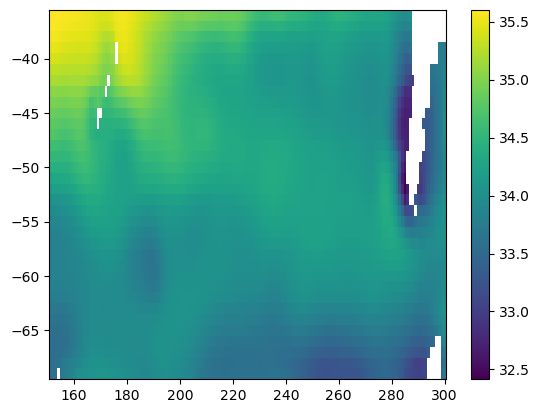

In [105]:
plt.figure()
plt.pcolormesh(spac_ds.coords['lon'], spac_ds.coords['lat'], spac_ds['salinity'].isel(time=0, depth=0))
plt.colorbar()

## Load the region and monthly anomalies into memory

In [106]:
%%time

for var in all_ds.data_vars:
    print(f"{var} Gb: {all_ds[var].nbytes * 1e-9}")


temperature Gb: 16.82456832
salinity Gb: 16.82456832
time_bnds Gb: 1.2864e-05
depth_bnds Gb: 0.000270144
CPU times: user 184 μs, sys: 53 μs, total: 237 μs
Wall time: 227 μs


In [107]:
%%time

spac_ds = spac_ds.compute()
sind_ds = sind_ds.compute()


CPU times: user 4min 5s, sys: 3min 23s, total: 7min 28s
Wall time: 8min 16s


In [108]:
print(sind_ds.temperature.shape)
print(spac_ds.temperature.shape)


(804, 42, 34, 110)
(804, 42, 34, 150)


## Make a new depth axis with finer resolution

In [109]:
new_depth = np.arange(5,2001,10)
new_depth_thick = np.arange(0,2001,10)
new_depth_thick[0] = 0; new_depth_thick[-1] = 2000; 
new_depth_thick = np.diff(new_depth_thick)
print(len(new_depth), len(new_depth_thick))

new_depth_thick = new_depth_thick[:, np.newaxis, np.newaxis]
new_depth_thick_ind = np.broadcast_to(new_depth_thick, (200,34,110))
new_depth_thick_pac = np.broadcast_to(new_depth_thick, (200,34,150))

dep_thick_ind = xr.DataArray(
    new_depth_thick_ind,
    dims=["depth", "lat", "lon"],
    coords={"depth": new_depth, "lon":sind_ds.coords["lon"].values, "lat":sind_ds.coords["lat"].values}
    )
dep_thick_pac = xr.DataArray(
    new_depth_thick_pac,
    dims=["depth", "lat", "lon"],
    coords={"depth": new_depth, "lon":spac_ds.coords["lon"].values, "lat":spac_ds.coords["lat"].values}
    )


200 200


## Regrid the EN4 data to a finer vertical resolution

In [110]:
%%time

sind_temp_lin = sind_ds.temperature.where(sind_ds.salinity>0.0, other=np.nan).sel(depth=slice(0,2000)).interp(depth=new_depth, method='linear')
sind_salt_lin = sind_ds.salinity.where(sind_ds.salinity>0.0, other=np.nan).sel(depth=slice(0,2000)).interp(depth=new_depth, method='linear')
spac_temp_lin = spac_ds.temperature.where(spac_ds.salinity>0.0, other=np.nan).sel(depth=slice(0,2000)).interp(depth=new_depth, method='linear')
spac_salt_lin = spac_ds.salinity.where(spac_ds.salinity>0.0, other=np.nan).sel(depth=slice(0,2000)).interp(depth=new_depth, method='linear')

sind_temp = sind_ds.temperature.where(sind_ds.salinity>0.0, other=np.nan).interpolate_na(dim='lon', method='linear').interpolate_na(dim='lat', method='linear').interpolate_na(dim='depth', method='linear')
sind_salt = sind_ds.salinity.where(sind_ds.salinity>0.0, other=np.nan).interpolate_na(dim='lon', method='linear').interpolate_na(dim='lat', method='linear').interpolate_na(dim='depth', method='linear')
spac_temp = spac_ds.temperature.where(spac_ds.salinity>0.0, other=np.nan).interpolate_na(dim='lon', method='linear').interpolate_na(dim='lat', method='linear').interpolate_na(dim='depth', method='linear')
spac_salt = spac_ds.salinity.where(spac_ds.salinity>0.0, other=np.nan).interpolate_na(dim='lon', method='linear').interpolate_na(dim='lat', method='linear').interpolate_na(dim='depth', method='linear')

sind_temp = sind_temp.where(~np.isnan(sind_salt),other=0.0).sel(depth=slice(0,2000))
sind_salt = sind_salt.where(~np.isnan(sind_salt),other=0.0).sel(depth=slice(0,2000))
spac_temp = spac_temp.where(~np.isnan(spac_salt),other=0.0).sel(depth=slice(0,2000))
spac_salt = spac_salt.where(~np.isnan(spac_salt),other=0.0).sel(depth=slice(0,2000))

sind_temp_cub = sind_temp.interp(depth=new_depth, method='cubic').where(sind_salt_lin>0.0, other=np.nan)
sind_salt_cub = sind_salt.interp(depth=new_depth, method='cubic').where(sind_salt_lin>0.0, other=np.nan)
spac_temp_cub = spac_temp.interp(depth=new_depth, method='cubic').where(spac_salt_lin>0.0, other=np.nan)
spac_salt_cub = spac_salt.interp(depth=new_depth, method='cubic').where(spac_salt_lin>0.0, other=np.nan)


CPU times: user 10min 42s, sys: 3min, total: 13min 42s
Wall time: 13min 32s


In [111]:
spac_temp_cub = spac_temp.interp(depth=new_depth, method='cubic').where(spac_salt_lin>0.0, other=np.nan)
spac_salt_cub = spac_salt.interp(depth=new_depth, method='cubic').where(spac_salt_lin>0.0, other=np.nan)


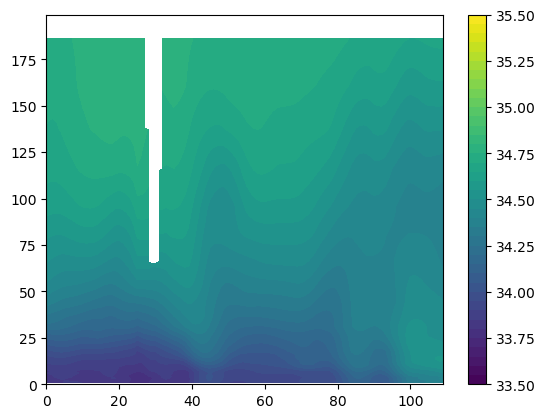

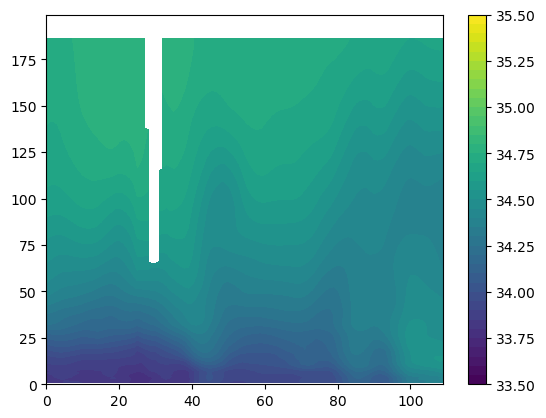

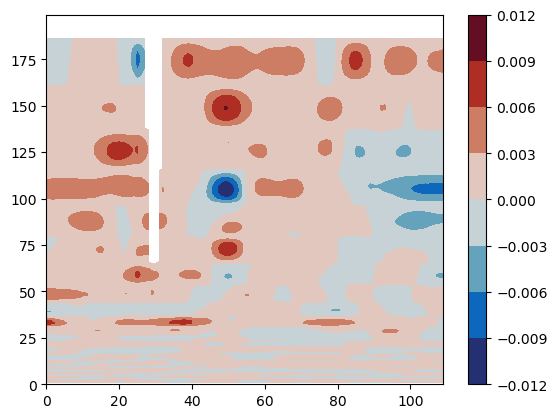

In [112]:
plt.figure()
p1 = plt.contourf(sind_salt_lin.isel(time=1).sel(lat=-50, method='nearest'), levels=np.arange(33.5,35.51,0.05))
plt.colorbar(p1)

plt.figure()
p1 = plt.contourf(sind_salt_cub.isel(time=1).sel(lat=-50, method='nearest'), levels=np.arange(33.5,35.51,0.05))
plt.colorbar(p1)

plt.figure()
p1 = plt.contourf((sind_salt_cub-sind_salt_lin).isel(time=1).sel(lat=-50, method='nearest'), cmap=cmo.balance)
plt.colorbar(p1)


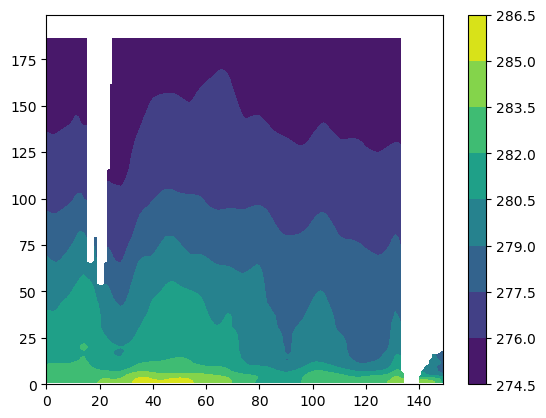

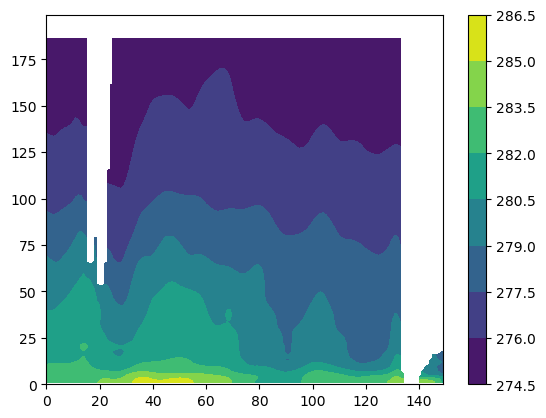

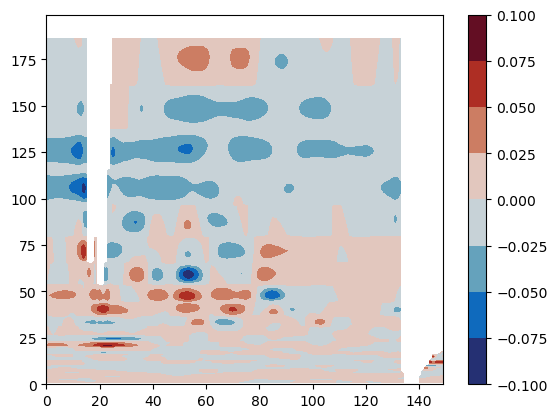

In [113]:
plt.figure()
p1 = plt.contourf(spac_temp_lin.isel(time=1).sel(lat=-50, method='nearest'))
plt.colorbar(p1)

plt.figure()
p1 = plt.contourf(spac_temp_cub.isel(time=1).sel(lat=-50, method='nearest'))
plt.colorbar(p1)

plt.figure()
p1 = plt.contourf((spac_temp_cub-spac_temp_lin).isel(time=1).sel(lat=-50, method='nearest'), cmap=cmo.balance)
plt.colorbar(p1)


## Calculate the density from temperature and salinity

In [114]:
%%time

sind_rho0_lin = gsw.density.sigma0(sind_salt_lin, sind_temp_lin-273.15)
sind_rho0_cub = gsw.density.sigma0(sind_salt_cub, sind_temp_cub-273.15)
spac_rho0_lin = gsw.density.sigma0(spac_salt_lin, spac_temp_lin-273.15)
spac_rho0_cub = gsw.density.sigma0(spac_salt_cub, spac_temp_cub-273.15)

# mask rho0 where there are zeros
sind_rho0_lin = sind_rho0_lin.where(sind_rho0_lin > 0.0, other=np.nan)
sind_rho0_cub = sind_rho0_cub.where(sind_rho0_cub > 0.0, other=np.nan)
spac_rho0_lin = spac_rho0_lin.where(spac_rho0_lin > 0.0, other=np.nan)
spac_rho0_cub = spac_rho0_cub.where(spac_rho0_cub > 0.0, other=np.nan)


CPU times: user 54.3 s, sys: 23 s, total: 1min 17s
Wall time: 1min 17s


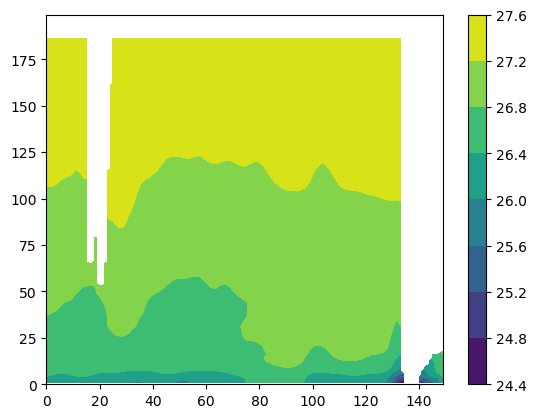

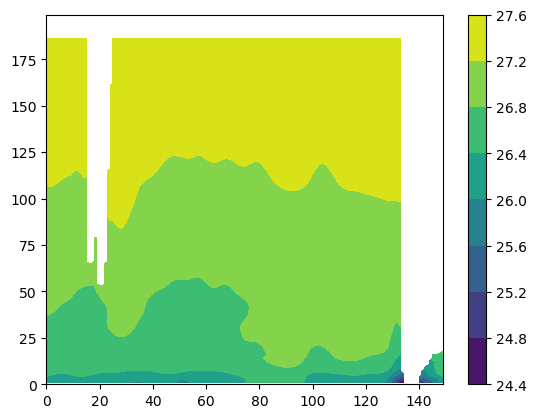

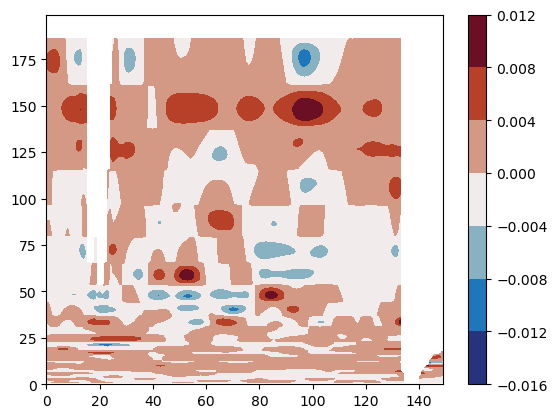

In [115]:
plt.figure()
p1 = plt.contourf(spac_rho0_lin.isel(time=1).sel(lat=-50, method='nearest'))
plt.colorbar(p1)

plt.figure()
p1 = plt.contourf(spac_rho0_cub.isel(time=1).sel(lat=-50, method='nearest'))
plt.colorbar(p1)

plt.figure()
p1 = plt.contourf((spac_rho0_cub-spac_rho0_lin).isel(time=1).sel(lat=-50, method='nearest'), cmap=cmo.balance)
plt.colorbar(p1)



## Find the mixed layer depth using the 0.1 kg/m3 criterion

In [116]:
def compute_mld(rho_profile, depth, criterion=0.1):
    """
    Compute the mixed layer depth (MLD) for a single vertical column.
    
    Parameters:
      rho_profile : 1D numpy array
          Density profile (kg/m^3) along the depth dimension.
      depth : 1D numpy array
          Depth levels corresponding to the density profile.
      criterion : float, optional
          The density difference criterion (default is 0.1 kg/m^3).
    
    Returns:
      mld : float
          The estimated mixed layer depth. Returns np.nan if the criterion
          is never reached.
    """
    # Calculate the density difference relative to the surface
    drho = rho_profile - rho_profile[0]
    
    # Find the first index where the density difference exceeds the criterion
    idx = np.where(drho >= criterion)[0]
    if len(idx) == 0:
        # If no level meets the criterion, return NaN (or you could choose the deepest level)
        return np.nan
    
    i = idx[0]
    
    # If the criterion is met in the very first level, return the top depth.
    if i == 0:
        return depth[0]
    
    # For a more accurate estimate, linearly interpolate between levels i-1 and i.
    d1, d2 = depth[i-1], depth[i]
    drho1, drho2 = drho[i-1], drho[i]
    
    # Calculate the fractional distance between the two depths where the threshold is met.
    frac = (criterion - drho1) / (drho2 - drho1)
    mld = d1 + frac * (d2 - d1)
    return mld



In [117]:
%%time

# Now, use xr.apply_ufunc to apply compute_mld to each vertical column in your dataset.
# Here, we assume that rho is an xarray DataArray with coordinate "depth".
sind_mld = xr.apply_ufunc(
    compute_mld,
    sind_rho0_cub.isel(depth=slice(1,120)),               # the density field
    sind_rho0_cub.isel(depth=slice(1,120))['depth'],      # the depth coordinate (assumed to be 1D)
    input_core_dims=[['depth'], ['depth']],  # indicate that both inputs have a "depth" dimension
    vectorize=True,    # vectorize over lat and lon
    kwargs={'criterion': 0.1},
    output_dtypes=[float]
)

spac_mld = xr.apply_ufunc(
    compute_mld,
    spac_rho0_cub.isel(depth=slice(1,120)),               # the density field
    spac_rho0_cub.isel(depth=slice(1,120))['depth'],      # the depth coordinate (assumed to be 1D)
    input_core_dims=[['depth'], ['depth']],  # indicate that both inputs have a "depth" dimension
    vectorize=True,    # vectorize over lat and lon
    kwargs={'criterion': 0.1},
    output_dtypes=[float]
)


CPU times: user 51.4 s, sys: 43.5 ms, total: 51.4 s
Wall time: 51.4 s


In [118]:
print(sind_mld.shape)
print(spac_mld.shape)


(804, 34, 110)
(804, 34, 150)


## Compute the area of each regular grid cell

In [119]:
%%time

# Earth’s radius in meters
R = 6_371_000  

# 1) Determine grid spacing in degrees
dlat = float(spac_ds.lat[1] - spac_ds.lat[0])  # assuming uniform lat spacing
dlon = float(spac_ds.lon[1] - spac_ds.lon[0])  # assuming uniform lon spacing

# 2) Convert degrees to radians
dlat_rad = np.deg2rad(dlat)
dlon_rad = np.deg2rad(dlon)

# 3) For small cells on a sphere, area ≈ R^2 * dlat * dlon * cos(lat)
#    We'll compute this for each latitude.
spac_lat_rad = np.deg2rad(spac_ds.lat)
sind_lat_rad = np.deg2rad(sind_ds.lat)

# cell_area will be 1D in 'lat' but we expand along 'lon' so it matches ds' shape
cell_area_1d = R**2 * dlat_rad * dlon_rad * np.cos(spac_lat_rad)
spac_cell_area = cell_area_1d.broadcast_like(spac_ds.lon)  # shape => (lat, lon)
cell_area_1d = R**2 * dlat_rad * dlon_rad * np.cos(sind_lat_rad)
sind_cell_area = cell_area_1d.broadcast_like(sind_ds.lon)  # shape => (lat, lon)

# 4) Attach as a new DataArray in the dataset
spac_mld['cell_area'] = spac_cell_area
spac_mld['cell_area'].attrs = {
    'units': 'm^2',
    'description': 'Approximate area of each lat/lon grid cell'
}
sind_mld['cell_area'] = sind_cell_area
sind_mld['cell_area'].attrs = {
    'units': 'm^2',
    'description': 'Approximate area of each lat/lon grid cell'
}


CPU times: user 14.3 ms, sys: 4.53 ms, total: 18.8 ms
Wall time: 20.2 ms


## Compute the monthly MLD anomaly

In [120]:
%%time

sind_mld_anom = sind_mld.sel(time=slice("2005-01-1", "2022-12-31")).groupby('time.month') - sind_mld.sel(time=slice("2005-01-1", "2022-12-31")).groupby('time.month').mean('time')
spac_mld_anom = spac_mld.sel(time=slice("2005-01-1", "2022-12-31")).groupby('time.month') - spac_mld.sel(time=slice("2005-01-1", "2022-12-31")).groupby('time.month').mean('time')


CPU times: user 79.7 ms, sys: 48.2 ms, total: 128 ms
Wall time: 1.26 s


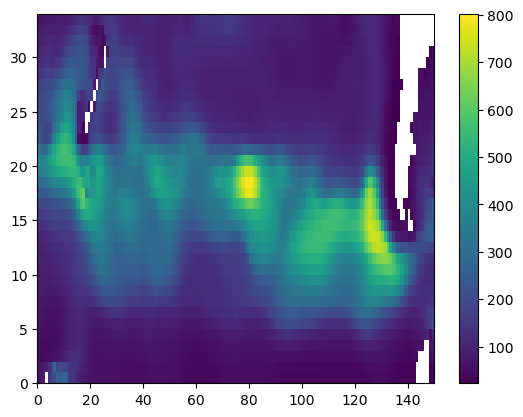

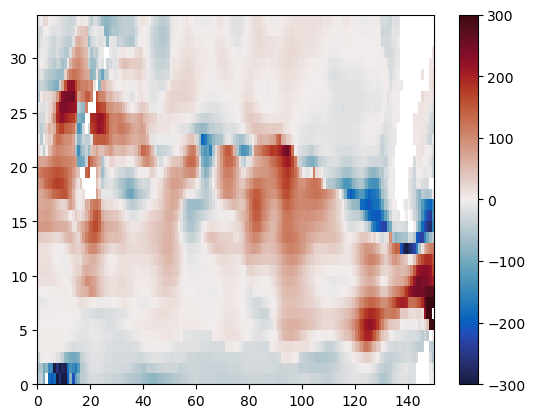

In [121]:
plt.figure()
plt.pcolormesh(spac_mld.groupby('time.month').mean('time').isel(month=8))
plt.colorbar()

plt.figure()
plt.pcolormesh(spac_mld_anom.isel(time=8+(12)), cmap=cmo.balance, vmin=-300, vmax=300)
plt.colorbar()

## Compute the EOFs for MLD in the South Indian and South Pacific regions

In [122]:
sind_mld_anom.coords['time']

<xarray.DataArray 'time' (time: 216)> Size: 2kB
array(['2005-01-16T12:00:00.000000000', '2005-02-15T00:00:00.000000000',
       '2005-03-16T12:00:00.000000000', ..., '2022-10-16T12:00:00.000000000',
       '2022-11-16T00:00:00.000000000', '2022-12-16T12:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2kB 2005-01-16T12:00:00 ... 2022-12-16T12:...
    month    (time) int64 2kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12

In [123]:
%%time

weights = sind_mld_anom['cell_area'] / sind_mld_anom['cell_area'].sum()
W_ind = weights**0.5
X = sind_mld_anom * W_ind
Xind = X.stack(space=("lat","lon")).fillna(0.0)

### SVD
U, S, V = np.linalg.svd(Xind.T.values, full_matrices=False)

### reconstruct the dimensions of the original data
U_ = Xind.T * 0 + U
U_ind = U_.unstack('space') * W_ind**(-1)
U_ind = U_ind.rename({"time":"mode"})
U_ind = U_ind.assign_coords({"mode":np.arange(len(S))})

S_ind = xr.DataArray(
    S,
    dims=["mode"],
    coords={"mode":np.arange(len(S))}
)

V_ind = xr.DataArray(
    V.T,
    dims=["time","mode"],
    coords={
        "time":Xind.coords['time'].values,
        "mode":np.arange(len(S))
    }
)

# variance explained
S2_ind = S_ind**2.0
VE_ind = S2_ind / S2_ind.sum()

print(np.shape(Xind.T))
print(np.shape(U_ind))
print(np.shape(S_ind))
print(np.shape(V_ind))
print(np.shape(VE_ind))

(3740, 216)
(216, 34, 110)
(216,)
(216, 216)
(216,)
CPU times: user 156 ms, sys: 39.5 ms, total: 195 ms
Wall time: 272 ms


In [124]:
%%time

weights = spac_mld_anom['cell_area'] / spac_mld_anom['cell_area'].sum()
W_pac = weights**0.5
X = spac_mld_anom * W_pac
Xpac = X.stack(space=("lat","lon")).fillna(0.0)

### SVD
U, S, V = np.linalg.svd(Xpac.T.values, full_matrices=False)

### reconstruct the dimensions of the original data
U_ = Xpac.T * 0 + U
U_pac = U_.unstack('space') * W_pac**(-1)
U_pac = U_pac.rename({"time":"mode"})
U_pac = U_pac.assign_coords({"mode":np.arange(len(S))})

S_pac = xr.DataArray(
    S,
    dims=["mode"],
    coords={"mode":np.arange(len(S))}
)

V_pac = xr.DataArray(
    V.T,
    dims=["time","mode"],
    coords={
        "time":Xpac.coords['time'].values,
        "mode":np.arange(len(S))
    }
)

# variance explained
S2_pac = S_pac**2.0
VE_pac = S2_pac / S2_pac.sum()

print(np.shape(Xpac.T))
print(np.shape(U_pac))
print(np.shape(S_pac))
print(np.shape(V_pac))
print(np.shape(VE_pac))

(5100, 216)
(216, 34, 150)
(216,)
(216, 216)
(216,)
CPU times: user 173 ms, sys: 21.1 ms, total: 194 ms
Wall time: 193 ms


## Have a look

Total variance explained in Indian by first 2 modes = 0.28509846825964746
Total variance explained in Pacific by first 2 modes = 0.2828654938639192


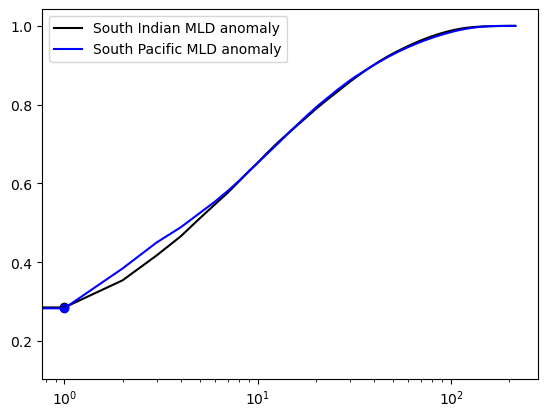

In [125]:
imodes = 1
print("Total variance explained in Indian by first %i modes ="%(imodes+1), VE_ind.cumsum().sel(mode=imodes).values)
print("Total variance explained in Pacific by first %i modes ="%(imodes+1), VE_pac.cumsum().sel(mode=imodes).values)

plt.figure()
plt.plot(np.arange(len(VE_ind)), VE_ind.cumsum(), color='k', label="South Indian MLD anomaly")
plt.plot(np.arange(len(VE_pac)), VE_pac.cumsum(), color='b', label="South Pacific MLD anomaly")
plt.scatter(imodes, VE_ind.cumsum().sel(mode=imodes), marker='o', color='k')
plt.scatter(imodes, VE_pac.cumsum().sel(mode=imodes), marker='o', color='b')
plt.legend()
plt.xscale('log')

Text(0.05, 1.05, 'j')

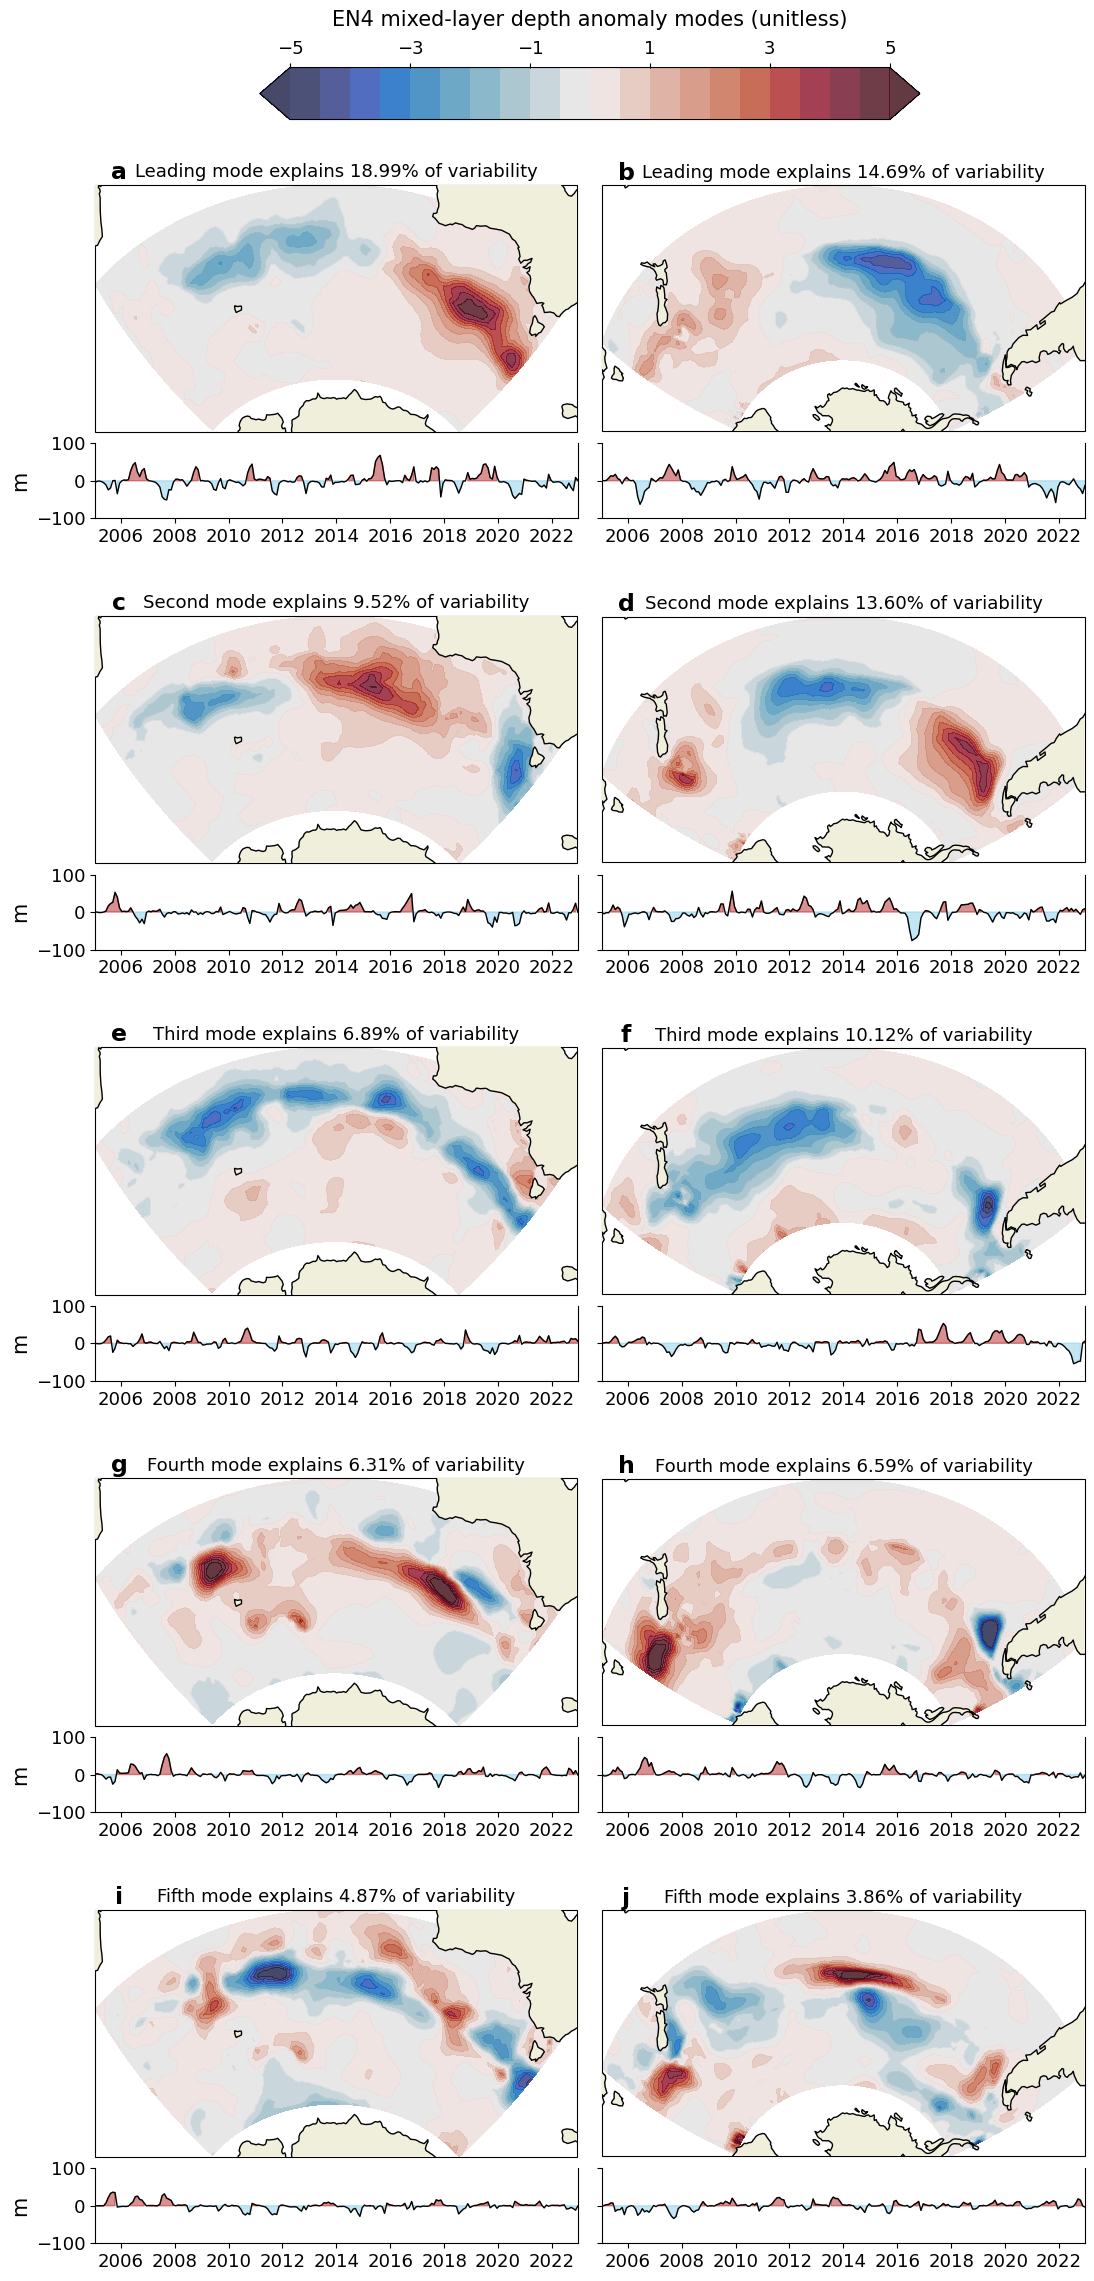

In [126]:

sind_proj = ccrs.Orthographic(central_latitude=-55, central_longitude=95)
spac_proj = ccrs.Orthographic(central_latitude=-60, central_longitude=225)

paclons = U_pac.coords['lon']
paclats = U_pac.coords['lat']
indlons = U_ind.coords['lon']
indlats = U_ind.coords['lat']


levs = np.arange(-5,5.1,0.5)
colmap = lighten(cmo.balance, 0.8)
fstic = 13
fslab = 15
wid = 1.0

fig = plt.figure(figsize=(11,26), facecolor='w')
gs = GridSpec(25,2)

ax1 = plt.subplot(gs[0:3,0], projection=sind_proj)
ax2 = plt.subplot(gs[0:3,1], projection=spac_proj)
ax1p = plt.subplot(gs[3,0])
ax2p = plt.subplot(gs[3,1])
ax3 = plt.subplot(gs[5:8,0], projection=sind_proj)
ax4 = plt.subplot(gs[5:8,1], projection=spac_proj)
ax3p = plt.subplot(gs[8,0])
ax4p = plt.subplot(gs[8,1])
ax5 = plt.subplot(gs[10:13,0], projection=sind_proj)
ax6 = plt.subplot(gs[10:13,1], projection=spac_proj)
ax5p = plt.subplot(gs[13,0])
ax6p = plt.subplot(gs[13,1])
ax7 = plt.subplot(gs[15:18,0], projection=sind_proj)
ax8 = plt.subplot(gs[15:18,1], projection=spac_proj)
ax7p = plt.subplot(gs[18,0])
ax8p = plt.subplot(gs[18,1])
ax9 = plt.subplot(gs[20:23,0], projection=sind_proj)
ax10 = plt.subplot(gs[20:23,1], projection=spac_proj)
ax9p = plt.subplot(gs[23,0])
ax10p = plt.subplot(gs[23,1])

ax1.add_feature(cfeature.LAND, zorder=3)
ax1.add_feature(cfeature.COASTLINE, zorder=3)
ax2.add_feature(cfeature.LAND, zorder=3)
ax2.add_feature(cfeature.COASTLINE, zorder=3)
ax3.add_feature(cfeature.LAND, zorder=3)
ax3.add_feature(cfeature.COASTLINE, zorder=3)
ax4.add_feature(cfeature.LAND, zorder=3)
ax4.add_feature(cfeature.COASTLINE, zorder=3)
ax5.add_feature(cfeature.LAND, zorder=3)
ax5.add_feature(cfeature.COASTLINE, zorder=3)
ax6.add_feature(cfeature.LAND, zorder=3)
ax6.add_feature(cfeature.COASTLINE, zorder=3)
ax7.add_feature(cfeature.LAND, zorder=3)
ax7.add_feature(cfeature.COASTLINE, zorder=3)
ax8.add_feature(cfeature.LAND, zorder=3)
ax8.add_feature(cfeature.COASTLINE, zorder=3)
ax9.add_feature(cfeature.LAND, zorder=3)
ax9.add_feature(cfeature.COASTLINE, zorder=3)
ax10.add_feature(cfeature.LAND, zorder=3)
ax10.add_feature(cfeature.COASTLINE, zorder=3)


p1 = ax1.contourf(indlons,indlats, U_ind.sel(mode=0), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p2 = ax2.contourf(paclons,paclats, U_pac.sel(mode=0)+1e-2, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
plt.text(0.5,1.05,'Leading mode explains %.2f%% of variability'%(VE_ind.sel(mode=0).values*100), transform=ax1.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Leading mode explains %.2f%% of variability'%(VE_pac.sel(mode=0).values*100), transform=ax2.transAxes, va='center', ha='center', fontsize=fstic)

tmp_ind = (S_ind.sel(mode=0) * V_ind.sel(mode=0))
tmp_pac = (S_pac.sel(mode=0) * V_pac.sel(mode=0))
ax1p.plot(V_ind.coords['time'], tmp_ind, color='k', linewidth=1.0)
ax2p.plot(V_pac.coords['time'], tmp_pac, color='k', linewidth=1.0)
ax1p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind > 0.0), color='firebrick', alpha=0.5)
ax1p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind < 0.0), color='skyblue', alpha=0.5)
ax2p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac > 0.0), color='firebrick', alpha=0.5)
ax2p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac < 0.0), color='skyblue', alpha=0.5)


imodes = 1 
p3 = ax3.contourf(indlons,indlats, U_ind.sel(mode=imodes)+1e-2, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p4 = ax4.contourf(paclons,paclats, U_pac.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
plt.text(0.5,1.05,'Second mode explains %.2f%% of variability'%(VE_ind.sel(mode=imodes).values*100), transform=ax3.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Second mode explains %.2f%% of variability'%(VE_pac.sel(mode=imodes).values*100), transform=ax4.transAxes, va='center', ha='center', fontsize=fstic)

tmp_ind = (S_ind.sel(mode=imodes) * V_ind.sel(mode=imodes))
tmp_pac = (S_pac.sel(mode=imodes) * V_pac.sel(mode=imodes))
ax3p.plot(V_ind.coords['time'], tmp_ind, color='k', linewidth=1.0)
ax4p.plot(V_pac.coords['time'], tmp_pac, color='k', linewidth=1.0)
ax3p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind > 0.0), color='firebrick', alpha=0.5)
ax3p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind < 0.0), color='skyblue', alpha=0.5)
ax4p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac > 0.0), color='firebrick', alpha=0.5)
ax4p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac < 0.0), color='skyblue', alpha=0.5)

imodes = 2 
p5 = ax5.contourf(indlons,indlats, U_ind.sel(mode=imodes)+1e-2, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p6 = ax6.contourf(paclons,paclats, U_pac.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
plt.text(0.5,1.05,'Third mode explains %.2f%% of variability'%(VE_ind.sel(mode=imodes).values*100), transform=ax5.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Third mode explains %.2f%% of variability'%(VE_pac.sel(mode=imodes).values*100), transform=ax6.transAxes, va='center', ha='center', fontsize=fstic)

tmp_ind = (S_ind.sel(mode=imodes) * V_ind.sel(mode=imodes))
tmp_pac = (S_pac.sel(mode=imodes) * V_pac.sel(mode=imodes))
ax5p.plot(V_ind.coords['time'], tmp_ind, color='k', linewidth=1.0)
ax6p.plot(V_pac.coords['time'], tmp_pac, color='k', linewidth=1.0)
ax5p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind > 0.0), color='firebrick', alpha=0.5)
ax5p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind < 0.0), color='skyblue', alpha=0.5)
ax6p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac > 0.0), color='firebrick', alpha=0.5)
ax6p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac < 0.0), color='skyblue', alpha=0.5)


imodes = 3 
p7 = ax7.contourf(indlons,indlats, U_ind.sel(mode=imodes)+1e-2, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p8 = ax8.contourf(paclons,paclats, U_pac.sel(mode=imodes)+1e-2, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
plt.text(0.5,1.05,'Fourth mode explains %.2f%% of variability'%(VE_ind.sel(mode=imodes).values*100), transform=ax7.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Fourth mode explains %.2f%% of variability'%(VE_pac.sel(mode=imodes).values*100), transform=ax8.transAxes, va='center', ha='center', fontsize=fstic)

tmp_ind = (S_ind.sel(mode=imodes) * V_ind.sel(mode=imodes))
tmp_pac = (S_pac.sel(mode=imodes) * V_pac.sel(mode=imodes))
ax7p.plot(V_ind.coords['time'], tmp_ind, color='k', linewidth=1.0)
ax8p.plot(V_pac.coords['time'], tmp_pac, color='k', linewidth=1.0)
ax7p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind > 0.0), color='firebrick', alpha=0.5)
ax7p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind < 0.0), color='skyblue', alpha=0.5)
ax8p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac > 0.0), color='firebrick', alpha=0.5)
ax8p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac < 0.0), color='skyblue', alpha=0.5)


imodes = 4 
p9 = ax9.contourf(indlons,indlats, U_ind.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p10 = ax10.contourf(paclons,paclats, U_pac.sel(mode=imodes)+1e-2, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
plt.text(0.5,1.05,'Fifth mode explains %.2f%% of variability'%(VE_ind.sel(mode=imodes).values*100), transform=ax9.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Fifth mode explains %.2f%% of variability'%(VE_pac.sel(mode=imodes).values*100), transform=ax10.transAxes, va='center', ha='center', fontsize=fstic)

tmp_ind = (S_ind.sel(mode=imodes) * V_ind.sel(mode=imodes))
tmp_pac = (S_pac.sel(mode=imodes) * V_pac.sel(mode=imodes))
ax9p.plot(V_ind.coords['time'], tmp_ind, color='k', linewidth=1.0)
ax10p.plot(V_pac.coords['time'], tmp_pac, color='k', linewidth=1.0)
ax9p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind > 0.0), color='firebrick', alpha=0.5)
ax9p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind < 0.0), color='skyblue', alpha=0.5)
ax10p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac > 0.0), color='firebrick', alpha=0.5)
ax10p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac < 0.0), color='skyblue', alpha=0.5)


ax1p.spines['top'].set_visible(False)
ax2p.spines['top'].set_visible(False)
ax3p.spines['top'].set_visible(False)
ax4p.spines['top'].set_visible(False)
ax5p.spines['top'].set_visible(False)
ax6p.spines['top'].set_visible(False)
ax7p.spines['top'].set_visible(False)
ax8p.spines['top'].set_visible(False)
ax9p.spines['top'].set_visible(False)
ax10p.spines['top'].set_visible(False)

ax1p.tick_params(labelsize=fstic)
ax2p.tick_params(labelsize=fstic, labelleft=False)
ax3p.tick_params(labelsize=fstic)
ax4p.tick_params(labelsize=fstic,labelleft=False)
ax5p.tick_params(labelsize=fstic)
ax6p.tick_params(labelsize=fstic,labelleft=False)
ax7p.tick_params(labelsize=fstic)
ax8p.tick_params(labelsize=fstic,labelleft=False)
ax9p.tick_params(labelsize=fstic)
ax10p.tick_params(labelsize=fstic,labelleft=False)

ax1p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax2p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax3p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax4p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax5p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax6p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax7p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax8p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax9p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax10p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())

y1 = -100.0; y2 = 100.0
ax1p.set_ylim(y1,y2)
ax2p.set_ylim(y1,y2)
ax3p.set_ylim(y1,y2)
ax4p.set_ylim(y1,y2)
ax5p.set_ylim(y1,y2)
ax6p.set_ylim(y1,y2)
ax7p.set_ylim(y1,y2)
ax8p.set_ylim(y1,y2)
ax9p.set_ylim(y1,y2)
ax10p.set_ylim(y1,y2)

ax1p.set_ylabel("m", fontsize=fslab)
ax3p.set_ylabel("m", fontsize=fslab)
ax5p.set_ylabel("m", fontsize=fslab)
ax7p.set_ylabel("m", fontsize=fslab)
ax9p.set_ylabel("m", fontsize=fslab)

cbax = fig.add_axes([0.2,0.9,0.6,0.02])
cbar1 = plt.colorbar(p1, cax=cbax, orientation='horizontal', ticks=levs[::4])
cbar1.ax.tick_params(labelsize=fstic, labelbottom=False, bottom=False, labeltop=True, top=True)
cbar1.ax.set_xlabel('EN4 mixed-layer depth anomaly modes (unitless)', fontsize=fslab, labelpad=10)
cbar1.ax.xaxis.set_label_position('top')

plt.subplots_adjust(left=0.05, top=0.875, right=0.95, bottom=0.05, wspace=0.05, hspace=0.15)

xx = 0.05; yy = 1.05
plt.text(xx,yy,'a', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,'b', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,'c', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,'d', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax4.transAxes)
plt.text(xx,yy,'e', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax5.transAxes)
plt.text(xx,yy,'f', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax6.transAxes)
plt.text(xx,yy,'g', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax7.transAxes)
plt.text(xx,yy,'h', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax8.transAxes)
plt.text(xx,yy,'i', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax9.transAxes)
plt.text(xx,yy,'j', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax10.transAxes)


In [82]:
fig.savefig("/home/581/pjb581/analysis_samw/fig-EN4_MLD_2005-2022_eofs.png", dpi=300)


## Calculate the MLD index from the leading two modes

In [127]:
%%time

### reconstruct X from the EOF modes 
X_pac_reconstructed = (U_pac * S_pac * V_pac.T)
X_ind_reconstructed = (U_ind * S_ind * V_ind.T)


CPU times: user 850 ms, sys: 1.02 s, total: 1.87 s
Wall time: 1.87 s


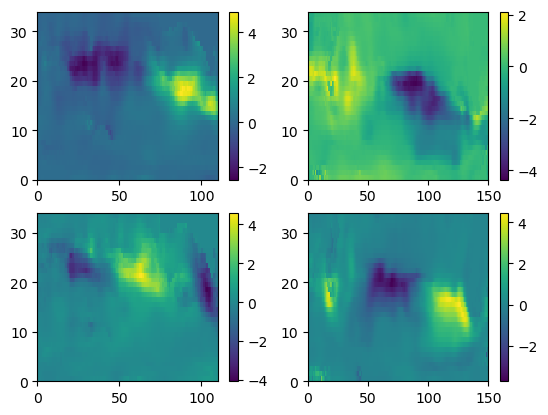

In [128]:
## Figure out what the leading two modes look like and make them similar to the pattern we have in the model

plt.figure()
gs = GridSpec(2,2)
ax1 = plt.subplot(gs[0,0])
ax2 = plt.subplot(gs[0,1])
ax3 = plt.subplot(gs[1,0])
ax4 = plt.subplot(gs[1,1])

p1 = ax1.pcolormesh(U_ind.sel(mode=0))
p2 = ax2.pcolormesh(U_pac.sel(mode=0))
p3 = ax3.pcolormesh(U_ind.sel(mode=1))
p4 = ax4.pcolormesh(U_pac.sel(mode=1))

plt.colorbar(p1, ax=ax1)
plt.colorbar(p2, ax=ax2)
plt.colorbar(p3, ax=ax3)
plt.colorbar(p4, ax=ax4)


In [129]:
%%time

# Pacific is positive then negative given spatial pattern of EOFs
I_pac_pos = ((S_pac.sel(mode=0) * V_pac.sel(mode=0).T * (-1) + S_pac.sel(mode=1) * V_pac.sel(mode=1).T * (-1) ) / 
            ((S_pac.sel(mode=0))**2 + (S_pac.sel(mode=1))**2)**0.5)
I_pac_neg = ((S_pac.sel(mode=0) * V_pac.sel(mode=0).T * (-1) - S_pac.sel(mode=1) * V_pac.sel(mode=1).T * (-1) ) / 
            ((S_pac.sel(mode=0))**2 + (S_pac.sel(mode=1))**2)**0.5)
# Indian is both negative given spatial pattern of EOFs
I_ind_pos = ((S_ind.sel(mode=0) * V_ind.sel(mode=0).T + S_ind.sel(mode=1) * V_ind.sel(mode=1).T ) / 
            ((S_ind.sel(mode=0))**2 + (S_ind.sel(mode=1))**2)**0.5)
I_ind_neg = ((S_ind.sel(mode=0) * V_ind.sel(mode=0).T - S_ind.sel(mode=1) * V_ind.sel(mode=1).T ) / 
            ((S_ind.sel(mode=0))**2 + (S_ind.sel(mode=1))**2)**0.5)

# Normalize
I_pac_pos = (I_pac_pos - I_pac_pos.mean()) / I_pac_pos.std()
I_pac_neg = (I_pac_neg - I_pac_neg.mean()) / I_pac_neg.std()
I_ind_pos = (I_ind_pos - I_ind_pos.mean()) / I_ind_pos.std()
I_ind_neg = (I_ind_neg - I_ind_neg.mean()) / I_ind_neg.std()


CPU times: user 43.3 ms, sys: 414 μs, total: 43.7 ms
Wall time: 479 ms


## Figure with EN4 (1958-2022)

Text(0.05, 1.05, 'j')

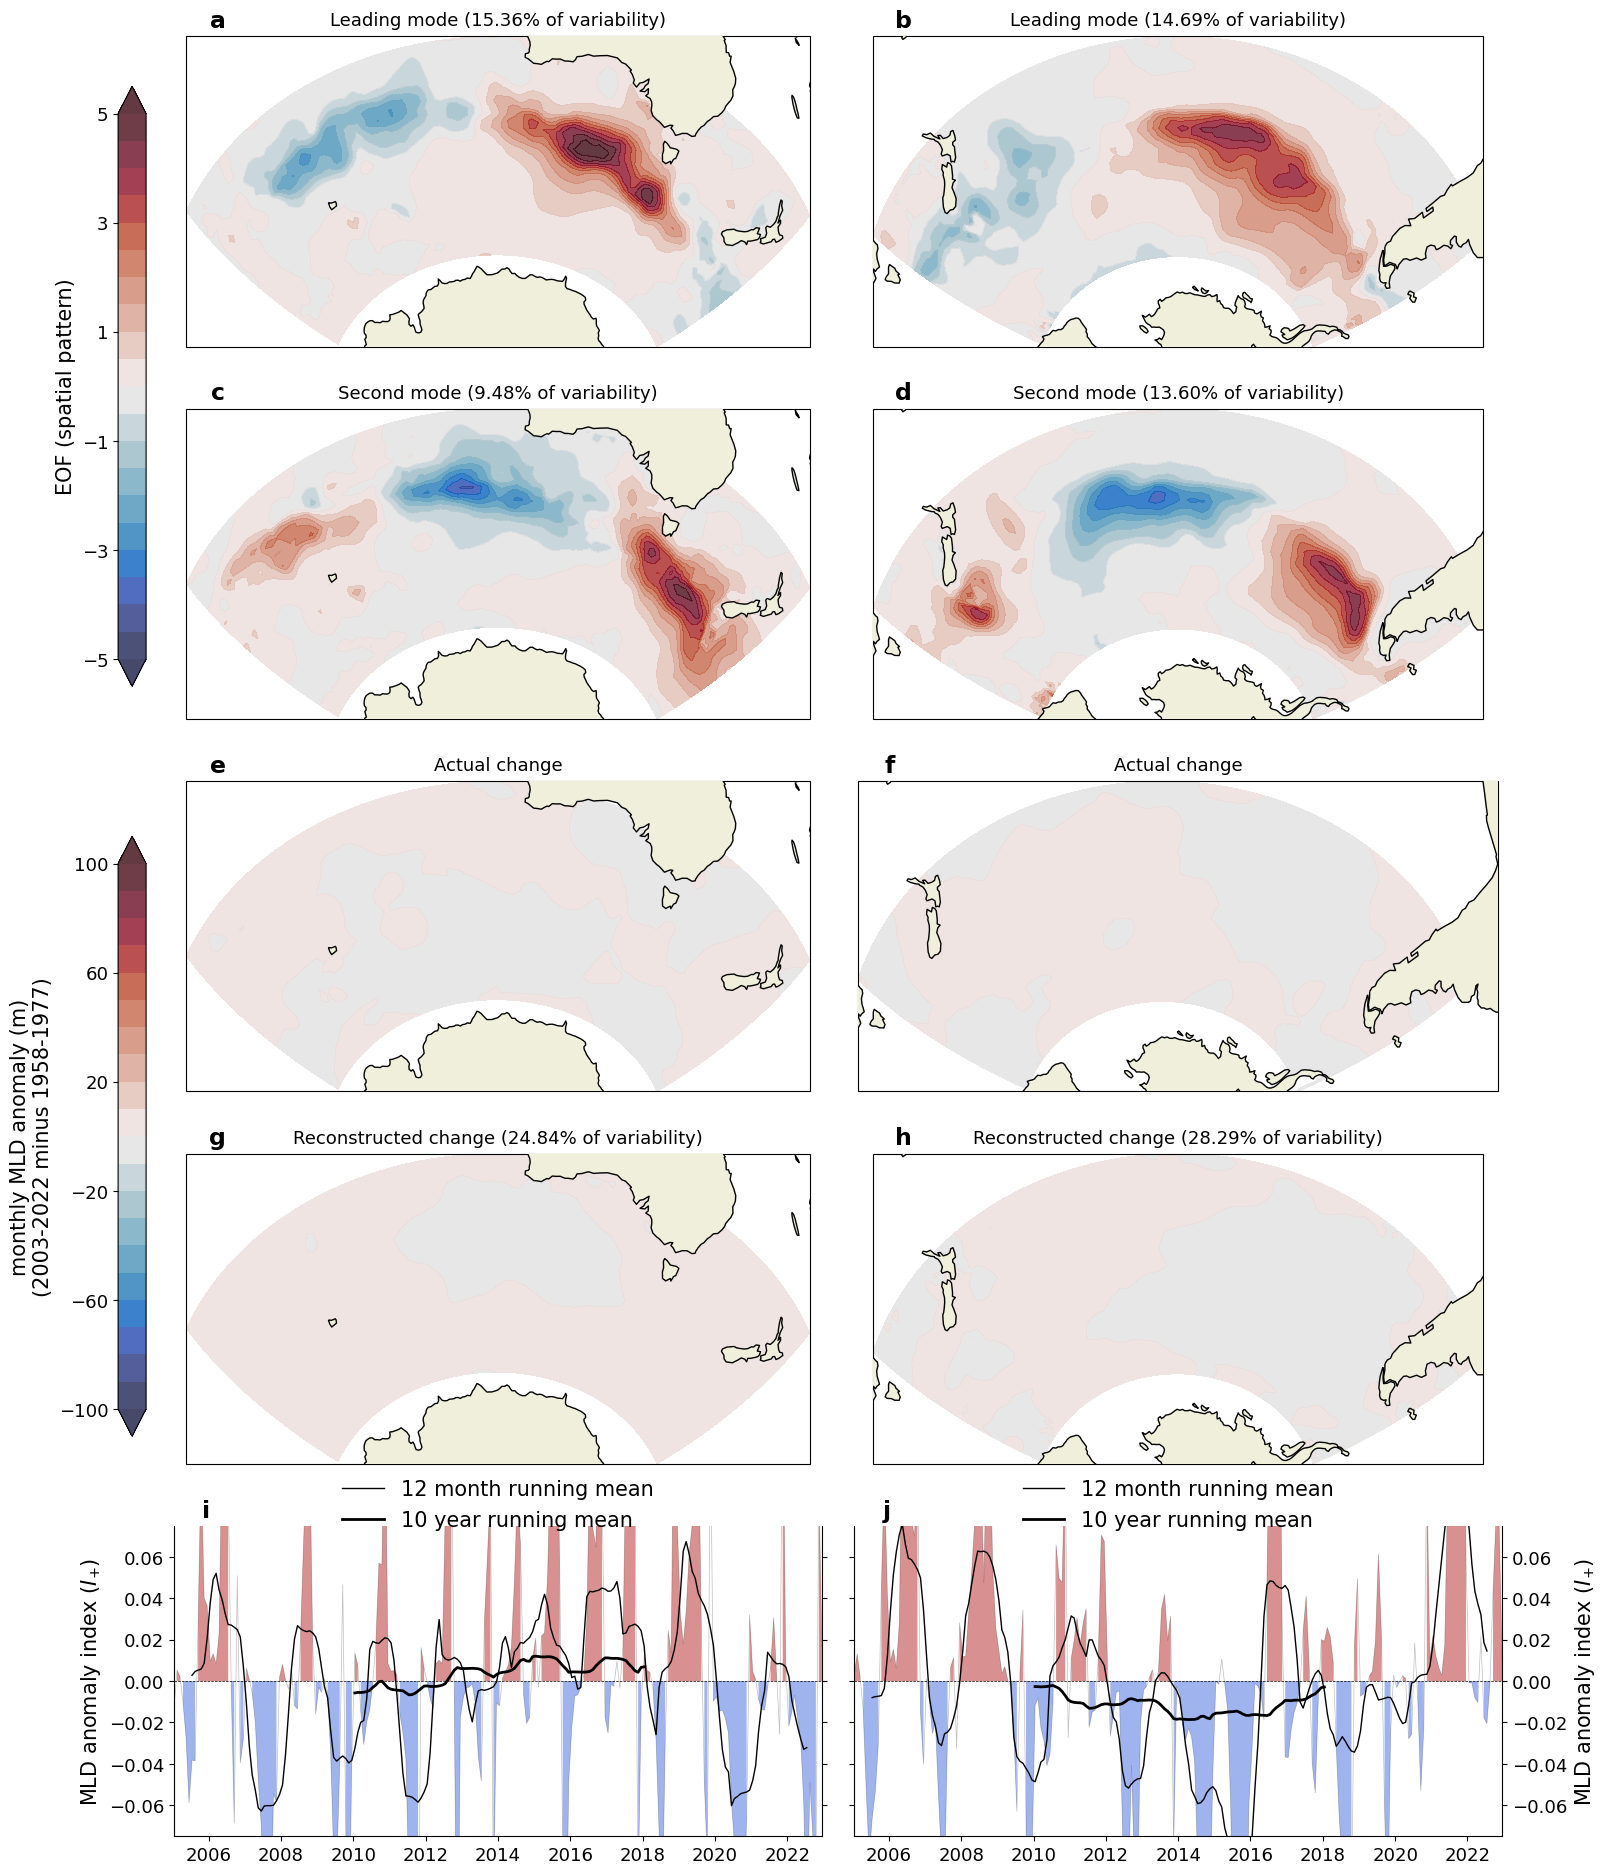

In [64]:
#%% Figure 1 (EN4)

sind_proj = ccrs.Orthographic(central_latitude=-55, central_longitude=110)
spac_proj = ccrs.Orthographic(central_latitude=-60, central_longitude=225)

paclons = U_pac.coords['lon']
paclats = U_pac.coords['lat']
indlons = U_ind.coords['lon']
indlats = U_ind.coords['lat']

levs1 = np.arange(-5,5.1,0.5)
levs2 = np.arange(-10,11,1)
colmap = lighten(cmo.balance, 0.8)
fstic = 13
fslab = 15
wid = 1.0

fig = plt.figure(figsize=(16,20), facecolor='w')
gs = GridSpec(5,2)

ax1 = plt.subplot(gs[0,0], projection=sind_proj)
ax2 = plt.subplot(gs[0,1], projection=spac_proj)
ax3 = plt.subplot(gs[1,0], projection=sind_proj)
ax4 = plt.subplot(gs[1,1], projection=spac_proj)
ax5 = plt.subplot(gs[2,0], projection=sind_proj)
ax6 = plt.subplot(gs[2,1], projection=spac_proj)
ax7 = plt.subplot(gs[3,0], projection=sind_proj)
ax8 = plt.subplot(gs[3,1], projection=spac_proj)
ax9 = plt.subplot(gs[4,0])
ax10 = plt.subplot(gs[4,1])

ax1.add_feature(cfeature.LAND, zorder=3)
ax1.add_feature(cfeature.COASTLINE, zorder=3)
ax2.add_feature(cfeature.LAND, zorder=3)
ax2.add_feature(cfeature.COASTLINE, zorder=3)
ax3.add_feature(cfeature.LAND, zorder=3)
ax3.add_feature(cfeature.COASTLINE, zorder=3)
ax4.add_feature(cfeature.LAND, zorder=3)
ax4.add_feature(cfeature.COASTLINE, zorder=3)
ax5.add_feature(cfeature.LAND, zorder=3)
ax5.add_feature(cfeature.COASTLINE, zorder=3)
ax6.add_feature(cfeature.LAND, zorder=3)
ax6.add_feature(cfeature.COASTLINE, zorder=3)
ax7.add_feature(cfeature.LAND, zorder=3)
ax7.add_feature(cfeature.COASTLINE, zorder=3)
ax8.add_feature(cfeature.LAND, zorder=3)
ax8.add_feature(cfeature.COASTLINE, zorder=3)


ax9.tick_params(labelsize=fstic, right=True)
ax10.tick_params(labelsize=fstic, labelleft=False, right=True, labelright=True)
ax9.spines['top'].set_visible(False)
ax10.spines['top'].set_visible(False)

p1 = ax1.contourf(indlons,indlats, U_ind.sel(mode=0) * (-1) + 1e-2, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs1, extend='both')
p2 = ax2.contourf(paclons,paclats, U_pac.sel(mode=0) * (-1), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs1, extend='both')
plt.text(0.5,1.05,'Leading mode (%.2f%% of variability)'%(VE_ind.sel(mode=0).values*100), transform=ax1.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Leading mode (%.2f%% of variability)'%(VE_pac.sel(mode=0).values*100), transform=ax2.transAxes, va='center', ha='center', fontsize=fstic)

imodes = 1 
p3 = ax3.contourf(indlons,indlats, U_ind.sel(mode=imodes) * (-1) + 1e-2, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs1, extend='both')
p4 = ax4.contourf(paclons,paclats, U_pac.sel(mode=imodes) * (-1), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs1, extend='both')
plt.text(0.5,1.05,'Second mode (%.2f%% of variability)'%(VE_ind.sel(mode=imodes).values*100), transform=ax3.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Second mode (%.2f%% of variability)'%(VE_pac.sel(mode=imodes).values*100), transform=ax4.transAxes, va='center', ha='center', fontsize=fstic)

paclons = spac_mld_anom.coords['lon']
paclats = spac_mld_anom.coords['lat']
indlons = sind_mld_anom.coords['lon']
indlats = sind_mld_anom.coords['lat']

p5 = ax5.contourf(indlons,indlats, sind_mld_anom.isel(time=slice(-240,-1)).mean(dim='time') - sind_mld_anom.isel(time=slice(0,240)).mean(dim="time"), \
                  transform=ccrs.PlateCarree(), cmap=colmap, levels=levs2, extend='both')
p6 = ax6.contourf(paclons,paclats, spac_mld_anom.isel(time=slice(-240,-1)).mean(dim='time') - spac_mld_anom.isel(time=slice(0,240)).mean(dim="time"), \
                  transform=ccrs.PlateCarree(), cmap=colmap, levels=levs2, extend='both')

paclons = U_pac.coords['lon']
paclats = U_pac.coords['lat']
indlons = U_ind.coords['lon']
indlats = U_ind.coords['lat']

p7 = ax7.contourf(indlons,indlats, X_ind_reconstructed.sel(mode=slice(0,imodes)).sum(dim='mode').isel(time=slice(-240,-1)).mean(dim="time") - \
                  X_ind_reconstructed.sel(mode=slice(0,imodes)).sum(dim='mode').isel(time=slice(0,240)).mean(dim="time") + 1e-2, \
                  transform=ccrs.PlateCarree(), cmap=colmap, levels=levs2, extend='both')
p8 = ax8.contourf(paclons,paclats, X_pac_reconstructed.sel(mode=slice(0,imodes)).sum(dim='mode').isel(time=slice(-240,-1)).mean(dim="time") - \
                  X_pac_reconstructed.sel(mode=slice(0,imodes)).sum(dim='mode').isel(time=slice(0,240)).mean(dim="time"), \
                  transform=ccrs.PlateCarree(), cmap=colmap, levels=levs2, extend='both')


ax9.plot(I_ind_pos.coords['time'], I_ind_pos, color='k', linewidth=0.5, linestyle='-', alpha=0.25)
ax9.plot(I_ind_pos.coords['time'], I_ind_pos*0, color='k', linewidth=0.5, linestyle='--', alpha=1.0)
ax9.plot(I_ind_pos.coords['time'], I_ind_pos.rolling(time=12, center=True).mean(), color='k', linewidth=1.0, linestyle='-', label="12 month running mean")
ax9.plot(I_ind_pos.coords['time'], I_ind_pos.rolling(time=120, center=True).mean(), color='k', linewidth=2.0, linestyle='-', label="10 year running mean")
ax10.plot(I_pac_pos.coords['time'], I_pac_pos, color='k', linewidth=0.5, linestyle='-', alpha=0.25)
ax10.plot(I_pac_pos.coords['time'], I_pac_pos*0, color='k', linewidth=0.5, linestyle='--', alpha=1.0)
ax10.plot(I_pac_pos.coords['time'], I_pac_pos.rolling(time=12, center=True).mean(), color='k', linewidth=1.0, linestyle='-', label="12 month running mean")
ax10.plot(I_pac_pos.coords['time'], I_pac_pos.rolling(time=120, center=True).mean(), color='k', linewidth=2.0, linestyle='-', label="10 year running mean")

ax9.legend(loc='upper center', frameon=False, fontsize=fslab, bbox_to_anchor=(0.5,1.21))
ax10.legend(loc='upper center', frameon=False, fontsize=fslab, bbox_to_anchor=(0.5,1.21))

ax9.fill_between(I_ind_pos.coords['time'], I_ind_pos.where(I_ind_pos > 0.0, other=np.nan), alpha=0.5, facecolor='firebrick')
ax9.fill_between(I_ind_pos.coords['time'], I_ind_pos.where(I_ind_pos < 0.0, other=np.nan), alpha=0.5, facecolor='royalblue')
ax10.fill_between(I_pac_pos.coords['time'], I_pac_pos.where(I_pac_pos > 0.0, other=np.nan), alpha=0.5, facecolor='firebrick')
ax10.fill_between(I_pac_pos.coords['time'], I_pac_pos.where(I_pac_pos < 0.0, other=np.nan), alpha=0.5, facecolor='royalblue')

#ax9.axvspan(I_ind_pos.coords['time'].sel(time="1987-01-01",method='nearest').values, \
#            I_ind_pos.coords['time'].sel(time="1988-12-31",method='nearest').values, color='goldenrod', alpha=0.25)
#ax10.axvspan(I_pac_pos.coords['time'].sel(time="1996-01-01",method='nearest').values, \
#             I_pac_pos.coords['time'].sel(time="1997-12-31",method='nearest').values, color='goldenrod', alpha=0.25)

ax9.set_xlim(I_pac_pos.coords['time'].min(), I_pac_pos.coords['time'].max())
ax10.set_xlim(I_pac_pos.coords['time'].min(), I_pac_pos.coords['time'].max())
ax9.set_ylabel("MLD anomaly index ($I_{MLD}$)", fontsize=fslab)
ax10.set_ylabel("MLD anomaly index ($I_{MLD}$)", fontsize=fslab)
ax10.yaxis.set_label_position('right')

ax9.set_ylim(-0.075,0.075)
ax10.set_ylim(-0.075,0.075)

cbax1 = fig.add_axes([0.085,0.625,0.0175,0.30])
cbax5 = fig.add_axes([0.085,0.25,0.0175,0.30])

cbar1 = plt.colorbar(p1, cax=cbax1, orientation='vertical', ticks=levs1[::4])
cbar1.ax.tick_params(labelsize=fstic, right=False, labelright=False, left=True, labelleft=True)
cbar1.ax.set_ylabel('EOF (spatial pattern)', fontsize=fslab)
cbar1.ax.yaxis.set_label_position('left')

cbar5 = plt.colorbar(p5, cax=cbax5, orientation='vertical', ticks=levs2[::4])
cbar5.ax.tick_params(labelsize=fstic, right=False, labelright=False, left=True, labelleft=True)
cbar5.ax.set_ylabel('monthly MLD anomaly (m)\n(2003-2022 minus 1958-1977)', fontsize=fslab)
cbar5.ax.yaxis.set_label_position('left')

plt.text(0.5,1.05,'Actual change', transform=ax5.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Actual change', transform=ax6.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Reconstructed change (%.2f%% of variability)'%(VE_ind.cumsum().sel(mode=imodes).values*100), transform=ax7.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Reconstructed change (%.2f%% of variability)'%(VE_pac.cumsum().sel(mode=imodes).values*100), transform=ax8.transAxes, va='center', ha='center', fontsize=fstic)

plt.subplots_adjust(left=0.12, top=0.95, right=0.95, bottom=0.05, wspace=0.05)

xx = 0.05; yy = 1.05
plt.text(xx,yy,'a', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,'b', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,'c', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,'d', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax4.transAxes)
plt.text(xx,yy,'e', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax5.transAxes)
plt.text(xx,yy,'f', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax6.transAxes)
plt.text(xx,yy,'g', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax7.transAxes)
plt.text(xx,yy,'h', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax8.transAxes)
plt.text(xx,yy,'i', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax9.transAxes)
plt.text(xx,yy,'j', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax10.transAxes)


In [52]:
fig.savefig('/home/581/pjb581/analysis_samw/fig-EN4mld_trend_reconstructed.png', dpi=300, bbox_inches='tight')


## Figure with EN4 (2005-2022)

Text(0.05, 1.05, 'j')

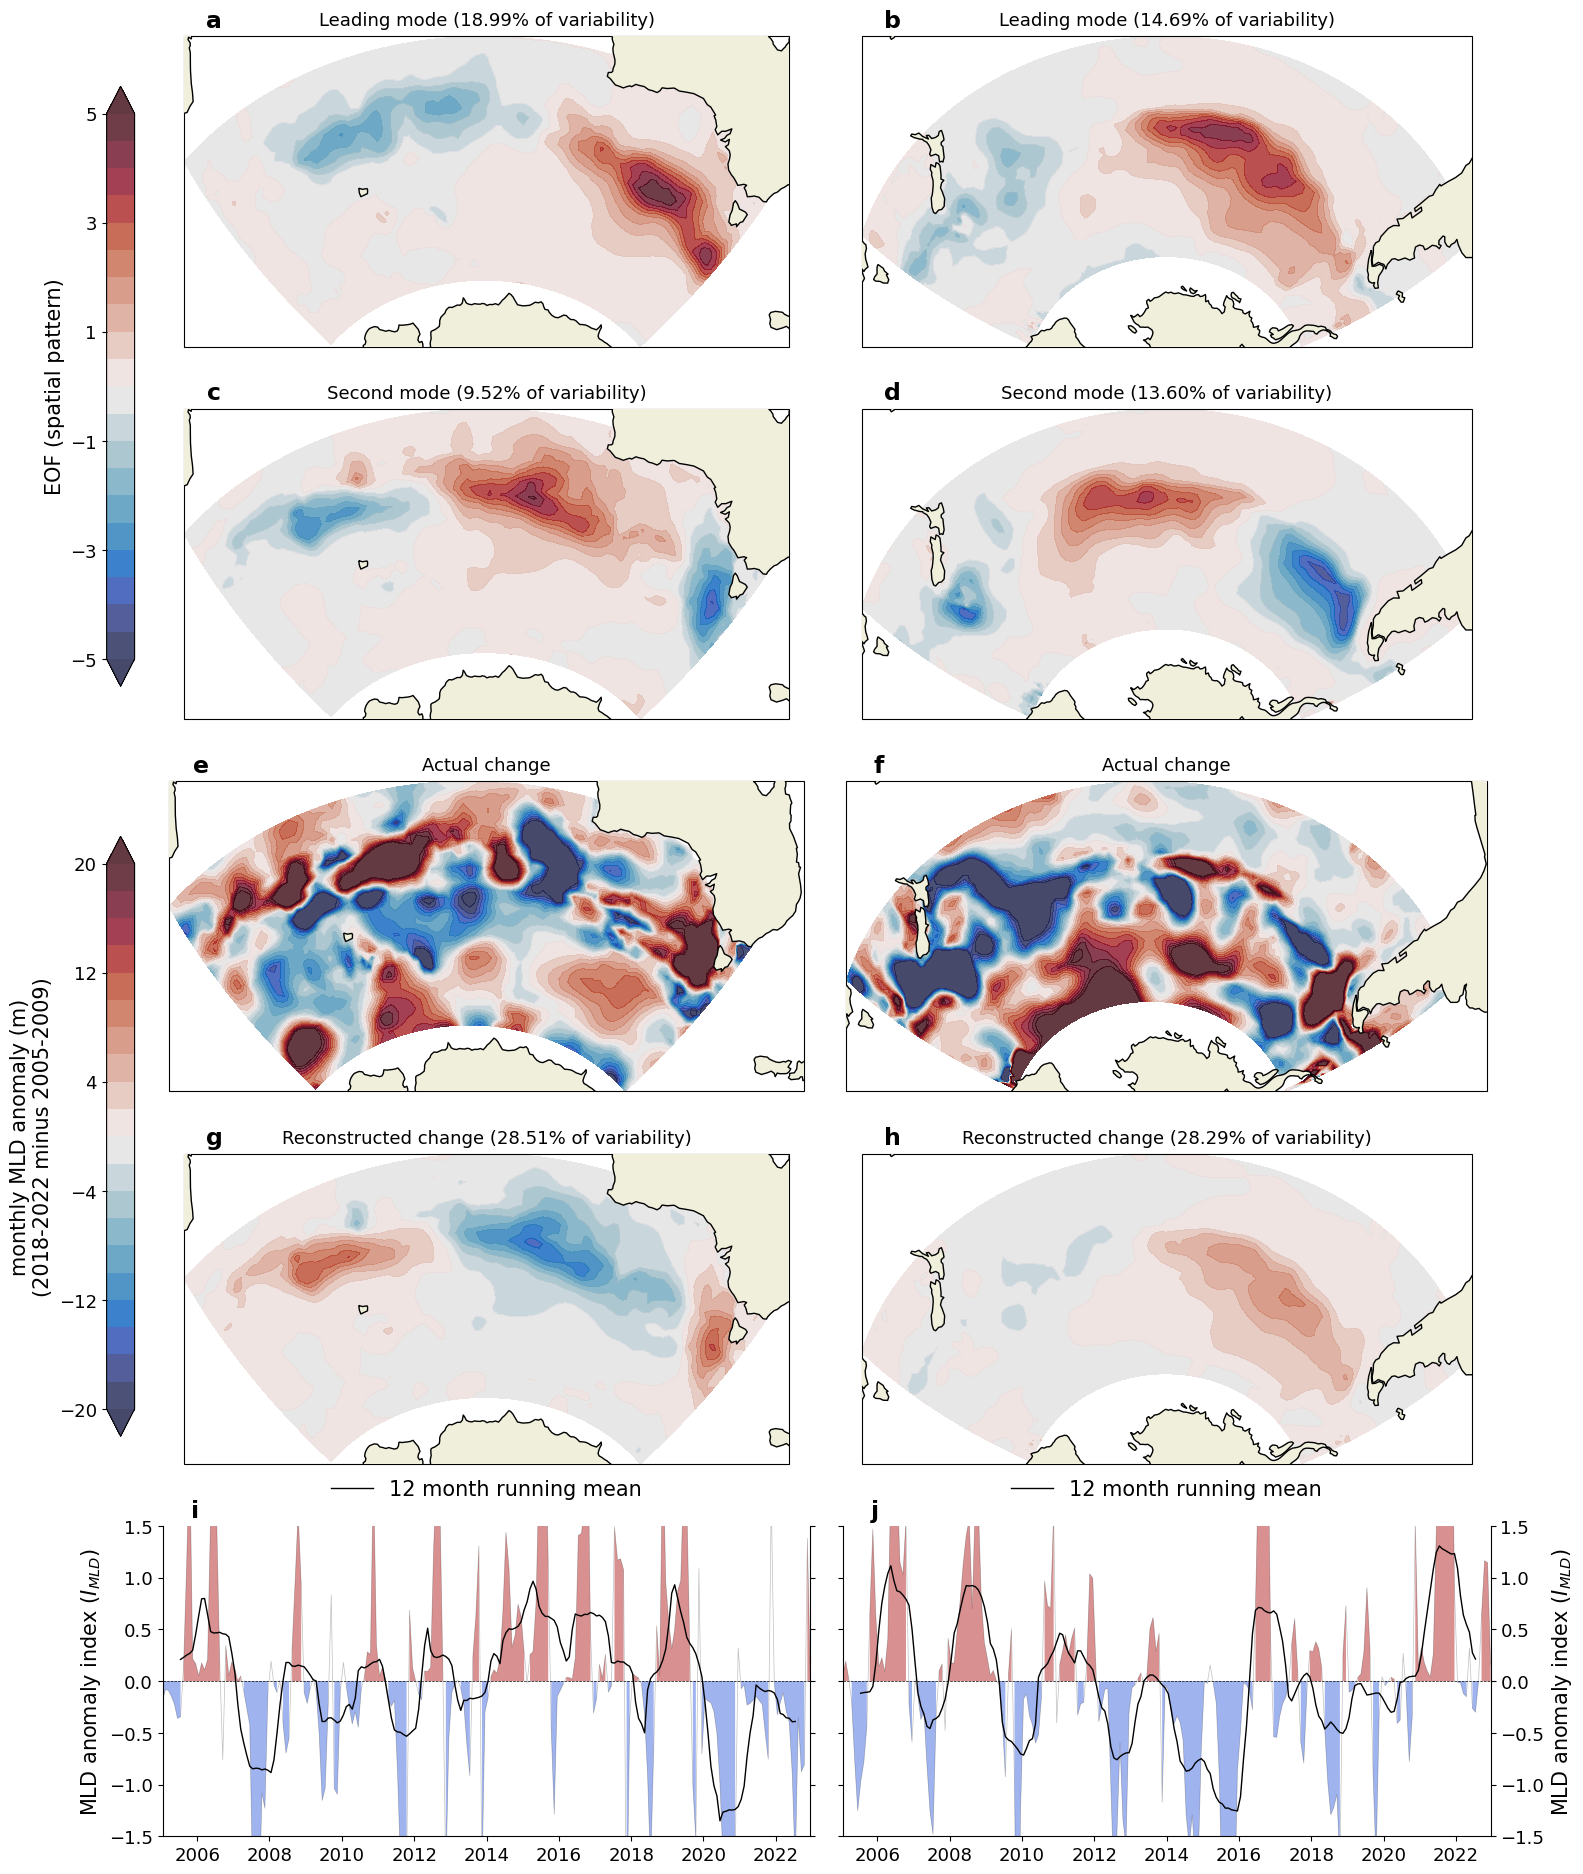

In [130]:
#%% Figure 1 (EN4)

sind_proj = ccrs.Orthographic(central_latitude=-55, central_longitude=95)
spac_proj = ccrs.Orthographic(central_latitude=-60, central_longitude=225)

paclons = U_pac.coords['lon']
paclats = U_pac.coords['lat']
indlons = U_ind.coords['lon']
indlats = U_ind.coords['lat']

levs1 = np.arange(-5,5.1,0.5)
levs2 = np.arange(-20,21,2)
colmap = lighten(cmo.balance, 0.8)
fstic = 13
fslab = 15
wid = 1.0

fig = plt.figure(figsize=(16,20), facecolor='w')
gs = GridSpec(5,2)

ax1 = plt.subplot(gs[0,0], projection=sind_proj)
ax2 = plt.subplot(gs[0,1], projection=spac_proj)
ax3 = plt.subplot(gs[1,0], projection=sind_proj)
ax4 = plt.subplot(gs[1,1], projection=spac_proj)
ax5 = plt.subplot(gs[2,0], projection=sind_proj)
ax6 = plt.subplot(gs[2,1], projection=spac_proj)
ax7 = plt.subplot(gs[3,0], projection=sind_proj)
ax8 = plt.subplot(gs[3,1], projection=spac_proj)
ax9 = plt.subplot(gs[4,0])
ax10 = plt.subplot(gs[4,1])

ax1.add_feature(cfeature.LAND, zorder=3)
ax1.add_feature(cfeature.COASTLINE, zorder=3)
ax2.add_feature(cfeature.LAND, zorder=3)
ax2.add_feature(cfeature.COASTLINE, zorder=3)
ax3.add_feature(cfeature.LAND, zorder=3)
ax3.add_feature(cfeature.COASTLINE, zorder=3)
ax4.add_feature(cfeature.LAND, zorder=3)
ax4.add_feature(cfeature.COASTLINE, zorder=3)
ax5.add_feature(cfeature.LAND, zorder=3)
ax5.add_feature(cfeature.COASTLINE, zorder=3)
ax6.add_feature(cfeature.LAND, zorder=3)
ax6.add_feature(cfeature.COASTLINE, zorder=3)
ax7.add_feature(cfeature.LAND, zorder=3)
ax7.add_feature(cfeature.COASTLINE, zorder=3)
ax8.add_feature(cfeature.LAND, zorder=3)
ax8.add_feature(cfeature.COASTLINE, zorder=3)


ax9.tick_params(labelsize=fstic, right=True)
ax10.tick_params(labelsize=fstic, labelleft=False, right=True, labelright=True)
ax9.spines['top'].set_visible(False)
ax10.spines['top'].set_visible(False)

p1 = ax1.contourf(indlons,indlats, U_ind.sel(mode=0) + 1e-2, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs1, extend='both')
p2 = ax2.contourf(paclons,paclats, U_pac.sel(mode=0) * (-1) , transform=ccrs.PlateCarree(), cmap=colmap, levels=levs1, extend='both')
plt.text(0.5,1.05,'Leading mode (%.2f%% of variability)'%(VE_ind.sel(mode=0).values*100), transform=ax1.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Leading mode (%.2f%% of variability)'%(VE_pac.sel(mode=0).values*100), transform=ax2.transAxes, va='center', ha='center', fontsize=fstic)

imodes = 1 
p3 = ax3.contourf(indlons,indlats, U_ind.sel(mode=imodes) + 1e-2, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs1, extend='both')
p4 = ax4.contourf(paclons,paclats, U_pac.sel(mode=imodes) * (-1), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs1, extend='both')
plt.text(0.5,1.05,'Second mode (%.2f%% of variability)'%(VE_ind.sel(mode=imodes).values*100), transform=ax3.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Second mode (%.2f%% of variability)'%(VE_pac.sel(mode=imodes).values*100), transform=ax4.transAxes, va='center', ha='center', fontsize=fstic)

paclons = spac_mld_anom.coords['lon']
paclats = spac_mld_anom.coords['lat']
indlons = sind_mld_anom.coords['lon']
indlats = sind_mld_anom.coords['lat']

p5 = ax5.contourf(indlons,indlats, sind_mld_anom.isel(time=slice(-60,-1)).mean(dim='time') - sind_mld_anom.isel(time=slice(0,60)).mean(dim="time"), \
                  transform=ccrs.PlateCarree(), cmap=colmap, levels=levs2, extend='both')
p6 = ax6.contourf(paclons,paclats, spac_mld_anom.isel(time=slice(-60,-1)).mean(dim='time') - spac_mld_anom.isel(time=slice(0,60)).mean(dim="time"), \
                  transform=ccrs.PlateCarree(), cmap=colmap, levels=levs2, extend='both')

paclons = U_pac.coords['lon']
paclats = U_pac.coords['lat']
indlons = U_ind.coords['lon']
indlats = U_ind.coords['lat']

p7 = ax7.contourf(indlons,indlats, X_ind_reconstructed.sel(mode=slice(0,imodes)).sum(dim='mode').isel(time=slice(-60,-1)).mean(dim="time") - \
                  X_ind_reconstructed.sel(mode=slice(0,imodes)).sum(dim='mode').isel(time=slice(0,60)).mean(dim="time") + 1e-2, \
                  transform=ccrs.PlateCarree(), cmap=colmap, levels=levs2, extend='both')
p8 = ax8.contourf(paclons,paclats, X_pac_reconstructed.sel(mode=slice(0,imodes)).sum(dim='mode').isel(time=slice(-60,-1)).mean(dim="time") - \
                  X_pac_reconstructed.sel(mode=slice(0,imodes)).sum(dim='mode').isel(time=slice(0,60)).mean(dim="time"), \
                  transform=ccrs.PlateCarree(), cmap=colmap, levels=levs2, extend='both')


ax9.plot(I_ind_pos.coords['time'], I_ind_pos, color='k', linewidth=0.5, linestyle='-', alpha=0.25)
ax9.plot(I_ind_pos.coords['time'], I_ind_pos*0, color='k', linewidth=0.5, linestyle='--', alpha=1.0)
ax9.plot(I_ind_pos.coords['time'], I_ind_pos.rolling(time=12, center=True).mean(), color='k', linewidth=1.0, linestyle='-', label="12 month running mean")
#ax9.plot(I_ind_pos.coords['time'], I_ind_pos.rolling(time=60, center=True).mean(), color='k', linewidth=2.0, linestyle='-', label="10 year running mean")
ax10.plot(I_pac_pos.coords['time'], I_pac_pos, color='k', linewidth=0.5, linestyle='-', alpha=0.25)
ax10.plot(I_pac_pos.coords['time'], I_pac_pos*0, color='k', linewidth=0.5, linestyle='--', alpha=1.0)
ax10.plot(I_pac_pos.coords['time'], I_pac_pos.rolling(time=12, center=True).mean(), color='k', linewidth=1.0, linestyle='-', label="12 month running mean")
#ax10.plot(I_pac_pos.coords['time'], I_pac_pos.rolling(time=60, center=True).mean(), color='k', linewidth=2.0, linestyle='-', label="10 year running mean")

ax9.legend(loc='upper center', frameon=False, fontsize=fslab, bbox_to_anchor=(0.5,1.21))
ax10.legend(loc='upper center', frameon=False, fontsize=fslab, bbox_to_anchor=(0.5,1.21))

ax9.fill_between(I_ind_pos.coords['time'], I_ind_pos.where(I_ind_pos > 0.0, other=np.nan), alpha=0.5, facecolor='firebrick')
ax9.fill_between(I_ind_pos.coords['time'], I_ind_pos.where(I_ind_pos < 0.0, other=np.nan), alpha=0.5, facecolor='royalblue')
ax10.fill_between(I_pac_pos.coords['time'], I_pac_pos.where(I_pac_pos > 0.0, other=np.nan), alpha=0.5, facecolor='firebrick')
ax10.fill_between(I_pac_pos.coords['time'], I_pac_pos.where(I_pac_pos < 0.0, other=np.nan), alpha=0.5, facecolor='royalblue')

#ax9.axvspan(I_ind_pos.coords['time'].sel(time="2006-01-01",method='nearest').values, \
#            I_ind_pos.coords['time'].sel(time="2006-12-31",method='nearest').values, color='goldenrod', alpha=0.25)
#ax9.axvspan(I_ind_pos.coords['time'].sel(time="2007-01-01",method='nearest').values, \
#            I_ind_pos.coords['time'].sel(time="2007-12-31",method='nearest').values, color='goldenrod', alpha=0.25)
#ax10.axvspan(I_pac_pos.coords['time'].sel(time="2006-01-01",method='nearest').values, \
#             I_pac_pos.coords['time'].sel(time="2006-12-31",method='nearest').values, color='goldenrod', alpha=0.25)
#ax10.axvspan(I_pac_pos.coords['time'].sel(time="2007-01-01",method='nearest').values, \
#             I_pac_pos.coords['time'].sel(time="2007-12-31",method='nearest').values, color='goldenrod', alpha=0.25)

ax9.set_xlim(I_pac_pos.coords['time'].min(), I_pac_pos.coords['time'].max())
ax10.set_xlim(I_pac_pos.coords['time'].min(), I_pac_pos.coords['time'].max())
ax9.set_ylabel("MLD anomaly index ($I_{MLD}$)", fontsize=fslab)
ax10.set_ylabel("MLD anomaly index ($I_{MLD}$)", fontsize=fslab)
ax10.yaxis.set_label_position('right')

ax9.set_ylim(-1.5,1.5)
ax10.set_ylim(-1.5,1.5)

cbax1 = fig.add_axes([0.085,0.625,0.0175,0.30])
cbax5 = fig.add_axes([0.085,0.25,0.0175,0.30])

cbar1 = plt.colorbar(p1, cax=cbax1, orientation='vertical', ticks=levs1[::4])
cbar1.ax.tick_params(labelsize=fstic, right=False, labelright=False, left=True, labelleft=True)
cbar1.ax.set_ylabel('EOF (spatial pattern)', fontsize=fslab)
cbar1.ax.yaxis.set_label_position('left')

cbar5 = plt.colorbar(p5, cax=cbax5, orientation='vertical', ticks=levs2[::4])
cbar5.ax.tick_params(labelsize=fstic, right=False, labelright=False, left=True, labelleft=True)
cbar5.ax.set_ylabel('monthly MLD anomaly (m)\n(2018-2022 minus 2005-2009)', fontsize=fslab)
cbar5.ax.yaxis.set_label_position('left')

plt.text(0.5,1.05,'Actual change', transform=ax5.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Actual change', transform=ax6.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Reconstructed change (%.2f%% of variability)'%(VE_ind.cumsum().sel(mode=imodes).values*100), transform=ax7.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Reconstructed change (%.2f%% of variability)'%(VE_pac.cumsum().sel(mode=imodes).values*100), transform=ax8.transAxes, va='center', ha='center', fontsize=fstic)

plt.subplots_adjust(left=0.12, top=0.95, right=0.95, bottom=0.05, wspace=0.05)

xx = 0.05; yy = 1.05
plt.text(xx,yy,'a', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,'b', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,'c', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,'d', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax4.transAxes)
plt.text(xx,yy,'e', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax5.transAxes)
plt.text(xx,yy,'f', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax6.transAxes)
plt.text(xx,yy,'g', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax7.transAxes)
plt.text(xx,yy,'h', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax8.transAxes)
plt.text(xx,yy,'i', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax9.transAxes)
plt.text(xx,yy,'j', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax10.transAxes)


In [131]:
fig.savefig('/home/581/pjb581/analysis_samw/fig-EN4mld_trend_reconstructed_2005-2022.png', dpi=300, bbox_inches='tight')

I_ind_pos.name = "I_MLD"
I_pac_pos.name = "I_MLD"
I_ind_neg.name = "I_MLD"
I_pac_neg.name = "I_MLD"

os.remove('/home/581/pjb581/analysis_samw/Ipos_ind_EN4_2005-2022.nc')
os.remove('/home/581/pjb581/analysis_samw/Ipos_pac_EN4_2005-2022.nc')
#os.remove('/home/581/pjb581/analysis_samw/Ineg_ind_EN4_2005-2022.nc')
#os.remove('/home/581/pjb581/analysis_samw/Ineg_pac_EN4_2005-2022.nc')

I_ind_pos.to_netcdf('/home/581/pjb581/analysis_samw/Ipos_ind_EN4_2005-2022.nc')
I_pac_pos.to_netcdf('/home/581/pjb581/analysis_samw/Ipos_pac_EN4_2005-2022.nc')
I_ind_neg.to_netcdf('/home/581/pjb581/analysis_samw/Ineg_ind_EN4_2005-2022.nc')
I_pac_neg.to_netcdf('/home/581/pjb581/analysis_samw/Ineg_pac_EN4_2005-2022.nc')


## Check the I+ index captures the MLD variations 

In [132]:
%%time

sind_ds_recon = U_ind * S_ind * V_ind
spac_ds_recon = U_pac * S_pac * V_pac


CPU times: user 1.66 s, sys: 1.34 s, total: 3 s
Wall time: 2.99 s


In [135]:
%%time

datapath = "/home/581/pjb581/analysis_samw"

Ipos_pac_EN4 = xr.open_dataset(datapath + "/Ipos_pac_EN4_2005-2022.nc").squeeze()
Ipos_ind_EN4 = xr.open_dataset(datapath + "/Ipos_ind_EN4_2005-2022.nc").squeeze()

Ipos_pac_sim = xr.open_dataset(datapath + "/Ipos_pac_2005-2022.nc").squeeze()
Ipos_ind_sim = xr.open_dataset(datapath + "/Ipos_ind_2005-2022.nc").squeeze()

Ipos_pac_EN4 = Ipos_pac_EN4["I_MLD"]
Ipos_ind_EN4 = Ipos_ind_EN4["I_MLD"]
Ipos_pac_sim = Ipos_pac_sim["I_MLD"]
Ipos_ind_sim = Ipos_ind_sim["I_MLD"]


CPU times: user 30.7 ms, sys: 14.8 ms, total: 45.5 ms
Wall time: 87.9 ms


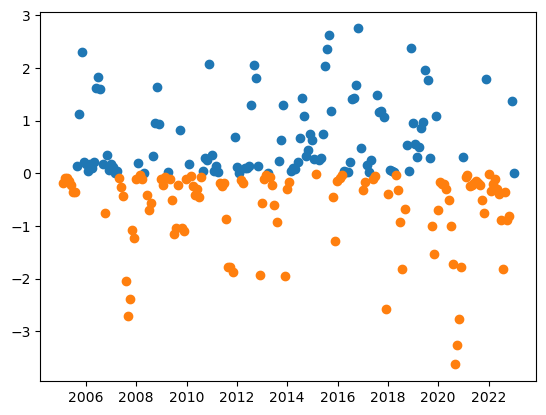

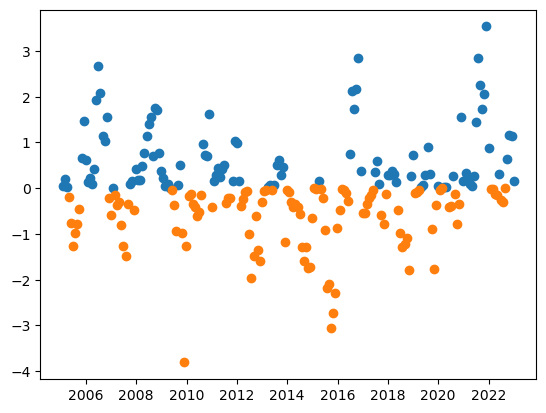

In [136]:
ind_pos = Ipos_ind_EN4 > 0.0
pac_pos = Ipos_pac_EN4 > 0.0
ind_neg = Ipos_ind_EN4 < 0.0
pac_neg = Ipos_pac_EN4 < 0.0

ind_pos_w = Ipos_ind_EN4[ind_pos]
pac_pos_w = Ipos_pac_EN4[pac_pos]
ind_neg_w = Ipos_ind_EN4[ind_neg]
pac_neg_w = Ipos_pac_EN4[pac_neg]

# resample the time axis to align with the EOF chl-a data
ind_pos_w = ind_pos_w.resample(time="ME").mean()
ind_neg_w = ind_neg_w.resample(time="ME").mean()
pac_pos_w = pac_pos_w.resample(time="ME").mean()
pac_neg_w = pac_neg_w.resample(time="ME").mean()

plt.figure()
plt.scatter(ind_pos_w.coords['time'], ind_pos_w)
plt.scatter(ind_neg_w.coords['time'], ind_neg_w)
plt.figure()
plt.scatter(pac_pos_w.coords['time'], pac_pos_w)
plt.scatter(pac_neg_w.coords['time'], pac_neg_w)


In [137]:
%%time

### full 
ind_recon_pos = (sind_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').resample(time="ME").mean() * ind_pos_w).sum(dim='time', skipna=True) / ind_pos_w.sum(dim='time', skipna=True)
ind_recon_neg = (sind_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').resample(time="ME").mean() * ind_neg_w).sum(dim='time', skipna=True) / ind_neg_w.sum(dim='time', skipna=True)
pac_recon_pos = (spac_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').resample(time="ME").mean() * pac_pos_w).sum(dim='time', skipna=True) / pac_pos_w.sum(dim='time', skipna=True)
pac_recon_neg = (spac_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').resample(time="ME").mean() * pac_neg_w).sum(dim='time', skipna=True) / pac_neg_w.sum(dim='time', skipna=True)

### only summer
ind_recon_pos_summer = (sind_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([12, 1, 2]), drop=True).resample(time="ME").mean() * ind_pos_w).sum(dim='time', skipna=True) / ind_pos_w.sum(dim='time', skipna=True)
ind_recon_neg_summer = (sind_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([12, 1, 2]), drop=True).resample(time="ME").mean() * ind_neg_w).sum(dim='time', skipna=True) / ind_neg_w.sum(dim='time', skipna=True)
pac_recon_pos_summer = (spac_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([12, 1, 2]), drop=True).resample(time="ME").mean() * pac_pos_w).sum(dim='time', skipna=True) / pac_pos_w.sum(dim='time', skipna=True)
pac_recon_neg_summer = (spac_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([12, 1, 2]), drop=True).resample(time="ME").mean() * pac_neg_w).sum(dim='time', skipna=True) / pac_neg_w.sum(dim='time', skipna=True)

### only winter
ind_recon_pos_winter = (sind_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([6, 7, 8, 9]), drop=True).resample(time="ME").mean() * ind_pos_w).sum(dim='time', skipna=True) / ind_pos_w.sum(dim='time', skipna=True)
ind_recon_neg_winter = (sind_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([6, 7, 8, 9]), drop=True).resample(time="ME").mean() * ind_neg_w).sum(dim='time', skipna=True) / ind_neg_w.sum(dim='time', skipna=True)
pac_recon_pos_winter = (spac_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([6, 7, 8, 9]), drop=True).resample(time="ME").mean() * pac_pos_w).sum(dim='time', skipna=True) / pac_pos_w.sum(dim='time', skipna=True)
pac_recon_neg_winter = (spac_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([6, 7, 8, 9]), drop=True).resample(time="ME").mean() * pac_neg_w).sum(dim='time', skipna=True) / pac_neg_w.sum(dim='time', skipna=True)


CPU times: user 1.5 s, sys: 312 ms, total: 1.81 s
Wall time: 1.83 s


In [138]:
%%time

sind_std = sind_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').std(dim='time')
spac_std = spac_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').std(dim='time')

ind_recon_pos_per = ind_recon_pos / sind_std * 100
ind_recon_neg_per = ind_recon_neg / sind_std * 100
pac_recon_pos_per = pac_recon_pos / spac_std * 100
pac_recon_neg_per = pac_recon_neg / spac_std * 100

sind_std = sind_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([12, 1, 2]), drop=True).std(dim='time')
spac_std = spac_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([12, 1, 2]), drop=True).std(dim='time')

ind_recon_pos_summer_per = ind_recon_pos_summer / sind_std * 100
ind_recon_neg_summer_per = ind_recon_neg_summer / sind_std * 100
pac_recon_pos_summer_per = pac_recon_pos_summer / spac_std * 100
pac_recon_neg_summer_per = pac_recon_neg_summer / spac_std * 100

sind_std = sind_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([6, 7, 8, 9]), drop=True).std(dim='time')
spac_std = spac_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([6, 7, 8, 9]), drop=True).std(dim='time')

ind_recon_pos_winter_per = ind_recon_pos_winter / sind_std * 100
ind_recon_neg_winter_per = ind_recon_neg_winter / sind_std * 100
pac_recon_pos_winter_per = pac_recon_pos_winter / spac_std * 100
pac_recon_neg_winter_per = pac_recon_neg_winter / spac_std * 100


CPU times: user 155 ms, sys: 120 ms, total: 276 ms
Wall time: 272 ms


Text(0.5, 1.1, 'MLD anomaly composite (I$_{MLD}$ > 0)')

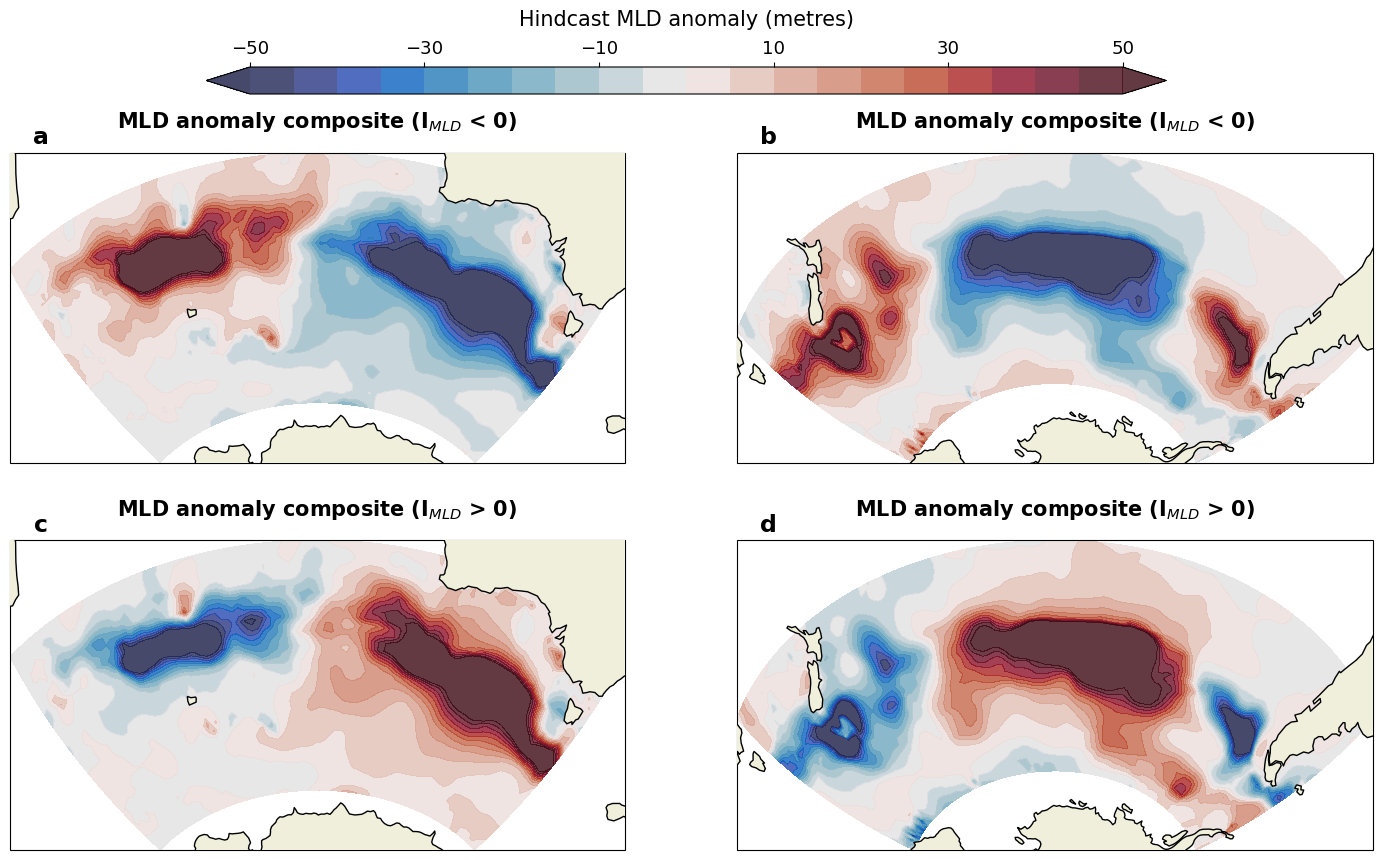

In [139]:
sind_proj = ccrs.Orthographic(central_latitude=ilat1+(ilat2-ilat1)*0.5, central_longitude=ilon1+(ilon2-ilon1)*0.5)
spac_proj = ccrs.Orthographic(central_latitude=ilat1+(ilat2-ilat1)*0.5, central_longitude=plon1+(plon2-plon1)*0.5)

paclons = U_pac.coords['lon']
paclats = U_pac.coords['lat']
indlons = U_ind.coords['lon']
indlats = U_ind.coords['lat']


levs = np.arange(-50,51,5)
colmap = lighten(cmo.balance, 0.8)
fstic = 13
fslab = 15
wid = 1.0

fig = plt.figure(figsize=(16,9), facecolor='w')
gs = GridSpec(2,2)

ax1 = plt.subplot(gs[0,0], projection=sind_proj)
ax2 = plt.subplot(gs[0,1], projection=spac_proj)
ax3 = plt.subplot(gs[1,0], projection=sind_proj)
ax4 = plt.subplot(gs[1,1], projection=spac_proj)

ax1.add_feature(cfeature.LAND, zorder=3)
ax1.add_feature(cfeature.COASTLINE, zorder=3)
ax2.add_feature(cfeature.LAND, zorder=3)
ax2.add_feature(cfeature.COASTLINE, zorder=3)
ax3.add_feature(cfeature.LAND, zorder=3)
ax3.add_feature(cfeature.COASTLINE, zorder=3)
ax4.add_feature(cfeature.LAND, zorder=3)
ax4.add_feature(cfeature.COASTLINE, zorder=3)

p1 = ax1.contourf(indlons,indlats, ind_recon_neg+1e-2, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p2 = ax2.contourf(paclons,paclats, pac_recon_neg, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')

p3 = ax3.contourf(indlons,indlats, ind_recon_pos+1e-2, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p4 = ax4.contourf(paclons,paclats, pac_recon_pos, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')

cbax = fig.add_axes([0.2,0.89,0.6,0.03])
cbar1 = plt.colorbar(p1, cax=cbax, orientation='horizontal', ticks=levs[::4])
cbar1.ax.tick_params(labelsize=fstic, labelbottom=False, bottom=False, labeltop=True, top=True)
cbar1.ax.set_xlabel('Hindcast MLD anomaly (metres)', fontsize=fslab, labelpad=10)
cbar1.ax.xaxis.set_label_position('top')

plt.subplots_adjust(left=0.05, top=0.825, right=0.95, bottom=0.05, wspace=0.05, hspace=0.25)


xx = 0.05; yy = 1.05
plt.text(xx,yy,'a', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,'b', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,'c', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,'d', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax4.transAxes)

xx = 0.5; yy = 1.10
plt.text(xx,yy,'MLD anomaly composite (I$_{MLD}$ < 0)', fontweight='bold', fontsize=fslab, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,'MLD anomaly composite (I$_{MLD}$ < 0)', fontweight='bold', fontsize=fslab, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,'MLD anomaly composite (I$_{MLD}$ > 0)', fontweight='bold', fontsize=fslab, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,'MLD anomaly composite (I$_{MLD}$ > 0)', fontweight='bold', fontsize=fslab, va='center', ha='center', transform=ax4.transAxes)


In [140]:
fig.savefig("/home/581/pjb581/analysis_samw/fig-MLD_composite_reconstructions_with_EN4_Ipos_Ineg.png", dpi=300)
